# Figure 4: Activity-Distance Compilation

Cache-first paper draft for activity-state spectra, axonal wave speeds, spike synchrony over distance, and axonal-only versus ephaptic-axonal model fits.

The figure cache is local to `outputs/figure4_activity_distance/`. Raw spike-state recomputation is explicit through `ALLOW_RAW_RECOMPUTE`; synchrony and wave analyses prefer existing caches because those are the expensive parts.


In [1]:

%matplotlib inline
import gc
import hashlib
import json
import math
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

repo_root = Path.cwd()
if not (repo_root / "ephax").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics import (
    aggregate_wave_results,
    build_burst_peak_aligned_events,
    binned_kde_peak_summary,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    compute_or_load_wave_result,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    extract_activity_state_ifr,
    load_wave_result_cache,
    save_wave_result_cache,
    wave_cache_dir,
)
from ephax.modeling import correlation_function
from ephax.plotting import PAPER_COLORS, apply_paper_style, export_figure

apply_paper_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)


/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configuration

`RUN_ALL_WELLS` and `RUN_ALL_DIVS` choose whether the figure uses the full matrix or a selected row/column/cell. The synchrony panel is based on cached activity-distance outputs; it will not silently run the full synchrony bootstrap if no cache is found.


## Cache Helpers


In [2]:

DATASET = "stim_removal_null"
RUN_ALL_WELLS = True
RUN_ALL_DIVS = True
WELL = 0
DIV = 14
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [12, 14, 21, 22, 23]

START_SEC = 0.0
END_SEC = 600.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

ALLOW_RAW_RECOMPUTE = True
FORCE_FIGURE4_RECOMPUTE = False
SAVE_FIGURE = True

IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
GAMMA_PEAK_MIN_HZ = 30.0

PRIMARY_LAG_WINDOW_MS = (-2.0, 2.0)
SYNC_ACTIVITY_SCOPE = "burst"
MIN_PAIRS_PER_DISTANCE_BIN = 20

WAVE_X_BIN_UM = 300.0
WAVE_PEAK_SEARCH_START_MS = -15.0
WAVE_PEAK_SEARCH_STOP_MS = 20.0
WAVE_TRACE_SMOOTH_SIGMA_MS = 2.0
WAVE_BIN_MS = 1.0
WAVE_MIN_ELECTRODES_PER_BIN = 5
WAVE_MIN_EVENTS_PER_BIN = 5
WAVE_BOOTSTRAP_REPS = 2000
WAVE_RANDOM_SEED = 0
ALLOW_WAVE_RAW_RECOMPUTE = True

PEAK_BAND_BOOTSTRAP_REPS = 20
PEAK_BAND_RANDOM_SEED = 0
PEAK_BANDS_HZ = {"gamma": (30.0, 80.0), "swr": (80.0, np.inf)}
MODEL_PEAK_BAND = "gamma"

MODEL_FIT_BOOTSTRAP_REPS = 1000
MODEL_FIT_RANDOM_SEED = 0
MODEL_INITIAL_AXONAL_DECAY_UM = 800.0
FIXED_LAMBDA_EPH_UM = 1_000_000.0
FIXED_EPHAPTIC_SPEED_DIV = 12
FIXED_EPHAPTIC_SPEED_SCOPE = "figure3_hierarchical_all_wells"

EXAMPLE_WELL = WELL
EXAMPLE_DIV = DIV

DATA_ROOT = repo_root / "ephax" / "data" / "stimRemovalNull"
FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"
OUTPUT_DIR = repo_root / "outputs" / "figure4_activity_distance"
TABLE_DIR = OUTPUT_DIR / "tables"
WAVE_CACHE_ROOT = repo_root / "outputs" / "stim_removal_null_wave_results"
ACTIVITY_DISTANCE_CACHE_ROOT = repo_root / "outputs" / "activity_distance"
FIGURE3_SPEED_PATH = repo_root / "outputs" / "figure3_lfp_event_front" / "tables" / "hierarchical_speed_summary.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

REQUESTED_WELLS = list(AGGREGATE_WELLS) if RUN_ALL_WELLS else [int(WELL)]
REQUESTED_DIVS = list(AGGREGATE_DIVS) if RUN_ALL_DIVS else [int(DIV)]
REQUESTED_WELLS, REQUESTED_DIVS


([0, 1, 2, 3, 4, 5], [12, 14, 21, 22, 23])

In [3]:

def stable_digest(obj, n=12):
    text = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:n]


def figure4_config_digest():
    payload = {
        "dataset": DATASET,
        "wells": REQUESTED_WELLS,
        "divs": REQUESTED_DIVS,
        "start": START_SEC,
        "end": END_SEC,
        "min_amp": MIN_AMP,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "ifr_grid_hz": IFR_GRID_HZ,
        "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
        "high_activity_mad_scale": HIGH_ACTIVITY_MAD_SCALE,
        "network_bin_ms": NETWORK_BIN_MS,
        "network_min_participation_fraction": NETWORK_MIN_PARTICIPATION_FRACTION,
        "gamma_peak_min_hz": GAMMA_PEAK_MIN_HZ,
        "peak_bands_hz": PEAK_BANDS_HZ,
        "model_peak_band": MODEL_PEAK_BAND,
        "peak_band_bootstrap_reps": PEAK_BAND_BOOTSTRAP_REPS,
        "peak_band_bootstrap_unit": "within_recording_ifr_kde_v1",
        "sync_activity_scope": SYNC_ACTIVITY_SCOPE,
        "primary_lag": PRIMARY_LAG_WINDOW_MS,
        "wave_settings": wave_settings(),
        "model_bootstrap_reps": MODEL_FIT_BOOTSTRAP_REPS,
        "lambda_eph_um": FIXED_LAMBDA_EPH_UM,
        "fixed_ephaptic_speed_div": FIXED_EPHAPTIC_SPEED_DIV,
        "fixed_ephaptic_speed_scope": FIXED_EPHAPTIC_SPEED_SCOPE,
        "figure3_speed_path": str(FIGURE3_SPEED_PATH),
        "loader_api": "tuple_file_info_v2",
        "wave_speed_schema": "hierarchical_per_well_v2",
        "active_ref_fallback": "recording_spike_counts_v1",
        "model_gamma_input": f"div_level_{MODEL_PEAK_BAND}_mean",
        "cache_schema": "compact_results_v3",
    }
    return stable_digest(payload)


def figure_cache_path():
    return OUTPUT_DIR / f"figure4_cache_{figure4_config_digest()}.pkl"


TABLE_CACHE_FILES = {
    "aggregate_kde_curve_df": "ifr_kde_curve_by_div_state.csv.gz",
    "gamma_peak_df": "ifr_kde_peak_summary.csv",
    "peak_band_summary_df": "ifr_kde_peak_band_summary.csv",
    "peak_band_bootstrap_df": "ifr_kde_peak_band_bootstrap.csv",
    "peak_band_recording_df": "ifr_kde_peak_band_recording_summary.csv",
    "peak_band_recording_bootstrap_df": "ifr_kde_peak_band_recording_bootstrap.csv.gz",
    "activity_summary_df": "activity_summary.csv",
    "activity_skipped_df": "activity_skipped.csv",
    "wave_per_well_summary_df": "wave_bootstrap_per_well_summary.csv",
    "wave_summary_df": "wave_bootstrap_summary.csv",
    "wave_bootstrap_df": "wave_bootstrap_samples.csv.gz",
    "primary_distance_summary": "excess_synchrony_distance.csv",
    "div_aggregate_synchrony": "excess_synchrony_grid_summary.csv",
    "div_aggregate_bootstrap": "excess_synchrony_div_bootstrap.csv.gz",
    "model_fit_by_div": "model_fit_by_div.csv",
    "model_fit_bootstrap": "model_fit_bootstrap.csv.gz",
    "model_prediction_by_div": "model_prediction_by_div.csv",
}

FIGURE4_PKL_SCHEMA = "figure4_compact_results_v4"
TABLE_CACHE_SCHEMA = "figure4_tables_compact_results_v3"
TABLE_MANIFEST_PATH = TABLE_DIR / "figure4_table_manifest.json"

COMPACT_CACHE_KEYS = {
    "config_digest",
    "cache_schema",
    "synchrony_cache_path",
    "fixed_ephaptic_speed_source",
    "aggregate_kde_by_div",
    "gamma_peak_df",
    "peak_band_summary_df",
    "peak_band_recording_df",
    "peak_band_recording_bootstrap_df",
    "activity_summary_df",
    "wave_per_well_summary_df",
    "wave_summary_df",
    "primary_distance_summary",
    "div_aggregate_synchrony",
    "model_fit_by_div",
    "model_prediction_by_div",
}

BULKY_CACHE_KEYS = {
    "records",
    "activity_value_df",
    "wave_results_by_div",
    "wave_per_well_bootstrap_df",
    "wave_bootstrap_df",
    "distance_bin_summary",
    "primary_bootstrap_bin",
    "div_aggregate_bootstrap",
    "model_fit_bootstrap",
    "model_prediction_bootstrap",
    "synchrony_cache_candidates",
}


def table_path(name):
    return TABLE_DIR / name


def write_table(df, name):
    path = table_path(name)
    if df is None:
        df = pd.DataFrame()
    if df.empty and len(df.columns) == 0:
        # A no-column DataFrame is "no result", not a valid table. Remove any stale
        # current-schema table at the exact path so it cannot be loaded later.
        if path.exists():
            path.unlink()
        return path
    df.to_csv(path, index=False, compression="infer")
    return path


def read_table(name):
    path = table_path(name)
    if not path.exists() or path.stat().st_size <= 1:
        return pd.DataFrame()
    try:
        return pd.read_csv(path, compression="infer")
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def write_table_manifest():
    manifest = {
        "schema": TABLE_CACHE_SCHEMA,
        "config_digest": figure4_config_digest(),
        "table_files": TABLE_CACHE_FILES,
    }
    TABLE_MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, sort_keys=True))
    return TABLE_MANIFEST_PATH


def read_table_manifest():
    if not TABLE_MANIFEST_PATH.exists():
        return {}
    try:
        return json.loads(TABLE_MANIFEST_PATH.read_text())
    except Exception:
        return {}


def table_manifest_matches_current_config():
    manifest = read_table_manifest()
    return (
        manifest.get("schema") == TABLE_CACHE_SCHEMA
        and manifest.get("config_digest") == figure4_config_digest()
    )


def aggregate_kde_to_frame(aggregate_kde):
    rows = []
    for div, state_map in (aggregate_kde or {}).items():
        for state, summary in (state_map or {}).items():
            if not isinstance(summary, dict):
                continue
            for array_name in ("plot_edges_hz", "counts", "grid_hz", "smoothed_counts"):
                values = np.asarray(summary.get(array_name, []), dtype=float)
                rows.extend(
                    {
                        "div": int(div),
                        "state": str(state),
                        "array_name": array_name,
                        "idx": int(idx),
                        "value": float(value),
                    }
                    for idx, value in enumerate(values)
                    if np.isfinite(value)
                )
    return pd.DataFrame(rows)


def aggregate_kde_from_frame(df):
    aggregate = {}
    if df is None or df.empty:
        return aggregate
    for (div, state), group in df.groupby(["div", "state"], dropna=False):
        summary = {}
        for array_name, array_df in group.groupby("array_name", dropna=False):
            ordered = array_df.sort_values("idx")
            summary[str(array_name)] = ordered["value"].to_numpy(float)
        aggregate.setdefault(int(div), {})[str(state)] = summary
    return aggregate


def make_compact_figure4_payload(payload):
    compact = {key: value for key, value in (payload or {}).items() if key in COMPACT_CACHE_KEYS and key not in BULKY_CACHE_KEYS}
    compact["config_digest"] = figure4_config_digest()
    compact["cache_schema"] = FIGURE4_PKL_SCHEMA
    return compact


def supplement_payload_from_tables(payload=None):
    payload = dict(payload or {})
    for key, filename in TABLE_CACHE_FILES.items():
        if key in payload and isinstance(payload[key], pd.DataFrame) and not payload[key].empty:
            continue
        df = read_table(filename)
        if not df.empty:
            payload[key] = df
    if "aggregate_kde_by_div" not in payload or not payload.get("aggregate_kde_by_div"):
        kde_df = payload.get("aggregate_kde_curve_df", pd.DataFrame())
        payload["aggregate_kde_by_div"] = aggregate_kde_from_frame(kde_df)
    return payload


def has_minimum_cached_results(payload):
    required = ["gamma_peak_df", "peak_band_summary_df", "peak_band_recording_bootstrap_df", "wave_summary_df", "primary_distance_summary", "div_aggregate_synchrony"]
    if int(MODEL_FIT_BOOTSTRAP_REPS) > 0:
        required.extend(["peak_band_bootstrap_df", "peak_band_recording_bootstrap_df", "div_aggregate_bootstrap", "model_fit_bootstrap"])
    return all(isinstance(payload.get(key), pd.DataFrame) and not payload[key].empty for key in required)


def load_figure4_tables_cache():
    if not table_manifest_matches_current_config():
        return None
    payload = supplement_payload_from_tables({"config_digest": figure4_config_digest()})
    if has_minimum_cached_results(payload):
        print("Loaded current-schema Figure 4 tables from outputs/figure4_activity_distance/tables; no raw recomputation needed.")
        return payload
    return None


def load_figure4_cache():
    path = figure_cache_path()
    if path.exists() and not FORCE_FIGURE4_RECOMPUTE:
        with path.open("rb") as f:
            payload = pickle.load(f)
        if payload.get("cache_schema") == FIGURE4_PKL_SCHEMA and payload.get("config_digest") == figure4_config_digest():
            return supplement_payload_from_tables(payload)
        print(f"Ignoring stale Figure 4 pickle {path.name}; schema/config does not match current notebook.")
    if FORCE_FIGURE4_RECOMPUTE:
        return None
    table_payload = load_figure4_tables_cache()
    if table_payload is not None:
        return table_payload
    return None


def save_figure4_cache(payload):
    path = figure_cache_path()
    compact = make_compact_figure4_payload(payload)
    with path.open("wb") as f:
        pickle.dump(compact, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"Wrote compact Figure 4 cache {path.name} ({size_mb:.2f} MB). Large bootstrap tables stay in CSV/GZip files.")
    return path

def bootstrap_ci(values, q=(0.025, 0.975)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return pd.Series({"ci_low": np.nan, "ci_high": np.nan})
    lo, hi = np.quantile(values, q)
    return pd.Series({"ci_low": float(lo), "ci_high": float(hi)})


def recording_id(well, div):
    return f"stimRemovalNull_well{int(well)}_DIV{int(div)}"


def aggregate_recording_id(div):
    wells = "-".join(str(int(w)) for w in AGGREGATE_WELLS)
    return f"aggregate_stim_removal_null_wells{wells}_DIVs{int(div)}"


def recording_path(well, div):
    return DATA_ROOT / f"well{int(well)}" / FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def wave_settings():
    return {
        "x_bin_um": WAVE_X_BIN_UM,
        "peak_search_start_ms": WAVE_PEAK_SEARCH_START_MS,
        "peak_search_stop_ms": WAVE_PEAK_SEARCH_STOP_MS,
        "trace_smooth_sigma_ms": WAVE_TRACE_SMOOTH_SIGMA_MS,
        "bin_ms": WAVE_BIN_MS,
        "min_electrodes_per_bin": WAVE_MIN_ELECTRODES_PER_BIN,
        "min_events_per_bin": WAVE_MIN_EVENTS_PER_BIN,
        "bootstrap_reps": WAVE_BOOTSTRAP_REPS,
        "random_seed": WAVE_RANDOM_SEED,
    }


## Activity-State IFR KDEs and Gamma Peaks


In [4]:

def active_electrode_fallback(recording):
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)
    electrodes, counts = np.unique(spike_electrodes, return_counts=True)
    if electrodes.size == 0:
        return np.array([], dtype=int)
    order = np.argsort(counts)[::-1]
    electrodes = electrodes[order]
    start = max(0, int(TOP_START))
    stop = min(int(TOP_STOP), electrodes.size)
    return electrodes[start:stop].astype(int)


def rebase_dataset_clock(ds):
    for rec in ds.recordings:
        offset_s = float(rec.start_time)
        rec.spikes = {**rec.spikes, "time": np.asarray(rec.spikes["time"], dtype=float) - offset_s}
        rec.end_time = float(rec.end_time) - offset_s
        rec.start_time = 0.0
    return ds


def recording_native_t0(path):
    with np.load(path, allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        return float(np.min(frameno) / sf_native) if frameno.size else 0.0


def load_recording(well, div):
    path = recording_path(well, div)
    if not path.exists():
        raise FileNotFoundError(path)
    rec_t0 = recording_native_t0(path)
    file_info = [(str(path), rec_t0 + float(START_SEC), rec_t0 + float(END_SEC), int(well))]
    ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))
    ds = rebase_dataset_clock(ds)
    rec = ds.recordings[0]
    refs = np.asarray(ds.select_ref_electrodes(PrepConfig(mode="top", top_start=int(TOP_START), top_stop=int(TOP_STOP)))[0], dtype=int)
    spike_electrodes = set(np.asarray(rec.spikes["electrode"], dtype=int).tolist())
    if refs.size == 0 or len(set(refs.tolist()) & spike_electrodes) == 0:
        refs = active_electrode_fallback(rec)
    return ds, rec, np.asarray(refs, dtype=int)


def state_kde_for_values(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0) & (values <= IFR_MAX_HZ)]
    summary = binned_kde_peak_summary(
        values,
        log_bins=True,
        n_bins=260,
        grid_size=8192,
        prominence_fraction=0.012,
        distance_fraction=0.006,
        bandwidth_scale=0.22,
        max_hz=IFR_MAX_HZ,
    )
    return summary, values



def bootstrap_peak_bands_for_recording(well, div, state, values):
    """Bootstrap KDE peak estimates by resampling IFR values within one recording/state."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0) & (values <= IFR_MAX_HZ)]
    rows = []
    if values.size == 0 or int(PEAK_BAND_BOOTSTRAP_REPS) <= 0:
        return rows
    seed = int(stable_digest({"seed": PEAK_BAND_RANDOM_SEED, "well": int(well), "div": int(div), "state": str(state)}, n=8), 16)
    rng = np.random.default_rng(seed)
    band_names = list(PEAK_BANDS_HZ.keys())
    for bootstrap_idx in range(int(PEAK_BAND_BOOTSTRAP_REPS)):
        sampled = rng.choice(values, size=values.size, replace=True)
        summary, _ = state_kde_for_values(sampled)
        by_band = {band: [] for band in band_names}
        for peak_hz, peak_count in zip(summary.get("peak_hz", []), summary.get("peak_counts", [])):
            band = classify_peak_band(float(peak_hz))
            if band is not None:
                by_band.setdefault(str(band), []).append((float(peak_hz), float(peak_count)))
        for band in band_names:
            peaks = by_band.get(str(band), [])
            if not peaks:
                continue
            peak_hz = np.asarray([item[0] for item in peaks], dtype=float)
            peak_counts = np.asarray([item[1] for item in peaks], dtype=float)
            rows.append({
                "well": int(well),
                "div": int(div),
                "state": str(state),
                "band": str(band),
                "bootstrap_idx": int(bootstrap_idx),
                "mean_peak_hz": float(np.nanmean(peak_hz)),
                "median_peak_hz": float(np.nanmedian(peak_hz)),
                "weighted_mean_peak_hz": float(np.average(peak_hz, weights=np.maximum(peak_counts, 0))) if np.any(peak_counts > 0) else float(np.nanmean(peak_hz)),
                "n_peaks": int(peak_hz.size),
                "n_ifr_values": int(values.size),
            })
    return rows


def compute_activity_kde_recording(well, div):
    ds, rec, refs = load_recording(well, div)
    population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    high_epochs, high_info = detect_high_activity_epochs(
        population.time_grid,
        population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
    burst_epochs = detect_participation_burst_epochs(
        participation,
        high_epochs,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    values_by_state = extract_activity_state_ifr(rec, refs, high_epochs, burst_epochs, max_hz=IFR_MAX_HZ)
    kde_by_state = {}
    peak_rows = []
    filtered_values_by_state = {}
    peak_band_bootstrap_rows = []
    for state in ("high_activity", "burst"):
        summary, values = state_kde_for_values(values_by_state.get(state, np.array([])))
        kde_by_state[state] = summary
        filtered_values_by_state[state] = np.asarray(values, dtype=float)
        peak_band_bootstrap_rows.extend(bootstrap_peak_bands_for_recording(well, div, state, values))
        for rank, (peak_hz, peak_count) in enumerate(zip(summary["peak_hz"], summary["peak_counts"]), start=1):
            if float(peak_hz) > float(GAMMA_PEAK_MIN_HZ):
                peak_rows.append({
                    "well": int(well),
                    "div": int(div),
                    "state": state,
                    "peak_hz": float(peak_hz),
                    "peak_count": float(peak_count),
                    "rank_within_state": int(rank),
                })
    summary_row = {
        "well": int(well),
        "div": int(div),
        "n_refs": int(len(refs)),
        "n_high_activity_epochs": int(len(high_epochs)),
        "n_burst_epochs": int(len(burst_epochs)),
        "high_activity_threshold_hz": float(high_info.get("threshold", np.nan)) if isinstance(high_info, dict) else np.nan,
    }
    return {
        "well": int(well),
        "div": int(div),
        "kde_by_state": kde_by_state,
        "peak_rows": peak_rows,
        "peak_band_bootstrap_rows": peak_band_bootstrap_rows,
        "filtered_values_by_state": filtered_values_by_state,
        "summary_row": summary_row,
    }


def build_activity_kde_payload():
    peak_rows = []
    peak_band_bootstrap_rows = []
    summary_rows = []
    skipped = []
    aggregate_values = {int(div): {"high_activity": [], "burst": []} for div in REQUESTED_DIVS}
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            try:
                item = compute_activity_kde_recording(well, div)
                peak_rows.extend(item["peak_rows"])
                peak_band_bootstrap_rows.extend(item.get("peak_band_bootstrap_rows", []))
                summary_rows.append(item["summary_row"])
                for state, values in item.get("filtered_values_by_state", {}).items():
                    values = np.asarray(values, dtype=float)
                    if values.size:
                        aggregate_values[int(div)].setdefault(str(state), []).append(values)
            except Exception as exc:
                skipped.append({"well": int(well), "div": int(div), "skip_reason": str(exc)})
            finally:
                gc.collect()
    peak_df = pd.DataFrame(peak_rows)
    recording_bootstrap_df = pd.DataFrame(peak_band_bootstrap_rows)
    summary_df = pd.DataFrame(summary_rows)
    skipped_df = pd.DataFrame(skipped)
    aggregate_kde = {}
    for div, state_map in aggregate_values.items():
        aggregate_kde[int(div)] = {}
        for state, arrays in state_map.items():
            if arrays:
                aggregate_kde[int(div)][state], _ = state_kde_for_values(np.concatenate(arrays))
            else:
                aggregate_kde[int(div)][state], _ = state_kde_for_values(np.array([], dtype=float))
    aggregate_kde_curve_df = aggregate_kde_to_frame(aggregate_kde)
    peak_band_summary_df, peak_band_bootstrap_df, peak_band_recording_df = summarize_peak_bands(recording_bootstrap_df)
    return {
        "aggregate_kde_by_div": aggregate_kde,
        "aggregate_kde_curve_df": aggregate_kde_curve_df,
        "gamma_peak_df": peak_df,
        "peak_band_summary_df": peak_band_summary_df,
        "peak_band_bootstrap_df": peak_band_bootstrap_df,
        "peak_band_recording_df": peak_band_recording_df,
        "peak_band_recording_bootstrap_df": recording_bootstrap_df,
        "activity_summary_df": summary_df,
        "activity_skipped_df": skipped_df,
    }


def classify_peak_band(peak_hz):
    peak_hz = float(peak_hz)
    for band, (low_hz, high_hz) in PEAK_BANDS_HZ.items():
        if peak_hz >= float(low_hz) and peak_hz < float(high_hz):
            return str(band)
    return None


def summarize_peak_bands(recording_bootstrap_df):
    """Summarize within-recording IFR-bootstrap KDE peak estimates.

    The bootstrap unit is the IFR sample inside each well/DIV/state recording. For
    the DIV-level model input we average recording/state bootstrap means at the
    same bootstrap index, so dense recordings or states do not dominate simply by
    contributing more IFR samples.
    """
    summary_cols = [
        "div", "band", "n_recordings", "n_recording_states", "n_peak_draws", "mean_peak_hz",
        "median_recording_peak_hz", "ci_low_hz", "ci_high_hz",
    ]
    boot_cols = [
        "div", "band", "bootstrap_idx", "mean_peak_hz", "n_recordings", "n_recording_states", "n_peaks",
    ]
    recording_cols = [
        "well", "div", "state", "band", "recording_mean_peak_hz", "recording_median_peak_hz",
        "ci_low_hz", "ci_high_hz", "n_bootstrap", "n_peak_draws", "median_n_ifr_values",
    ]
    if recording_bootstrap_df is None or recording_bootstrap_df.empty or "mean_peak_hz" not in recording_bootstrap_df.columns:
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)
    df = recording_bootstrap_df.copy()
    required = {"well", "div", "state", "band", "bootstrap_idx", "mean_peak_hz"}
    if not required.issubset(df.columns):
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)
    df["mean_peak_hz"] = pd.to_numeric(df["mean_peak_hz"], errors="coerce")
    df = df[np.isfinite(df["mean_peak_hz"])].copy()
    if df.empty:
        return pd.DataFrame(columns=summary_cols), pd.DataFrame(columns=boot_cols), pd.DataFrame(columns=recording_cols)

    recording_rows = []
    for (well, div, state, band), group in df.groupby(["well", "div", "state", "band"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        recording_rows.append({
            "well": int(well),
            "div": int(div),
            "state": str(state),
            "band": str(band),
            "recording_mean_peak_hz": float(np.nanmean(values)),
            "recording_median_peak_hz": float(np.nanmedian(values)),
            "ci_low_hz": float(np.nanquantile(values, 0.025)),
            "ci_high_hz": float(np.nanquantile(values, 0.975)),
            "n_bootstrap": int(values.size),
            "n_peak_draws": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
            "median_n_ifr_values": float(pd.to_numeric(group.get("n_ifr_values", pd.Series(dtype=float)), errors="coerce").median()) if "n_ifr_values" in group else np.nan,
        })
    recording_df = pd.DataFrame(recording_rows, columns=recording_cols)

    boot_rows = []
    for (div, band, bootstrap_idx), group in df.groupby(["div", "band", "bootstrap_idx"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        boot_rows.append({
            "div": int(div),
            "band": str(band),
            "bootstrap_idx": int(bootstrap_idx),
            "mean_peak_hz": float(np.nanmean(values)),
            "n_recordings": int(group[["well", "div"]].drop_duplicates().shape[0]),
            "n_recording_states": int(group[["well", "div", "state"]].drop_duplicates().shape[0]),
            "n_peaks": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
        })
    boot_df = pd.DataFrame(boot_rows, columns=boot_cols)

    summary_rows = []
    for (div, band), group in boot_df.groupby(["div", "band"], dropna=False):
        values = pd.to_numeric(group["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        rec_group = recording_df[(recording_df["div"].astype(int) == int(div)) & (recording_df["band"].astype(str) == str(band))]
        summary_rows.append({
            "div": int(div),
            "band": str(band),
            "n_recordings": int(rec_group[["well", "div"]].drop_duplicates().shape[0]) if not rec_group.empty else int(group["n_recordings"].max()),
            "n_recording_states": int(rec_group[["well", "div", "state"]].drop_duplicates().shape[0]) if not rec_group.empty else int(group["n_recording_states"].max()),
            "n_peak_draws": int(pd.to_numeric(group.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()),
            "mean_peak_hz": float(np.nanmean(values)),
            "median_recording_peak_hz": float(np.nanmedian(rec_group["recording_median_peak_hz"].to_numpy(float))) if not rec_group.empty else np.nan,
            "ci_low_hz": float(np.nanquantile(values, 0.025)),
            "ci_high_hz": float(np.nanquantile(values, 0.975)),
        })
    return pd.DataFrame(summary_rows, columns=summary_cols), boot_df, recording_df


## Wave-Speed Cache Loading


In [5]:

def load_wave_cache_for_recording(well, div):
    rid = recording_id(well, div)
    cache_dir = wave_cache_dir(WAVE_CACHE_ROOT, rid, **wave_settings())
    cached = load_wave_result_cache(cache_dir)
    if cached is not None:
        return cached, cache_dir, "per_well_cache"
    recording_root = WAVE_CACHE_ROOT / rid
    if recording_root.exists():
        fallback_dirs = sorted(
            {path.parent for path in recording_root.glob("*/fit_summary.csv")},
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        # Prefer the exact peak window, smoothing, and binning even if bootstrap count changed.
        preferred = []
        fallback = []
        key_fragments = [
            f"xbin{WAVE_X_BIN_UM:g}".replace(".", "p"),
            f"peak{WAVE_PEAK_SEARCH_START_MS:g}to{WAVE_PEAK_SEARCH_STOP_MS:g}".replace(".", "p").replace("-", "m"),
            f"smooth{WAVE_TRACE_SMOOTH_SIGMA_MS:g}".replace(".", "p"),
            f"bin{WAVE_BIN_MS:g}".replace(".", "p"),
            f"minelec{WAVE_MIN_ELECTRODES_PER_BIN}",
            f"minevents{WAVE_MIN_EVENTS_PER_BIN}",
        ]
        for fallback_dir in fallback_dirs:
            name = fallback_dir.name
            if all(fragment in name for fragment in key_fragments):
                preferred.append(fallback_dir)
            else:
                fallback.append(fallback_dir)
        for fallback_dir in preferred + fallback:
            cached = load_wave_result_cache(fallback_dir)
            if cached is not None:
                return cached, fallback_dir, "per_well_cache_fallback"
    return None, cache_dir, "missing"


def compute_wave_cache_for_recording(well, div):
    ds, rec, refs = load_recording(well, div)
    if refs.size == 0:
        raise ValueError("No selected reference electrodes for wave analysis.")
    aligned, _ = build_burst_peak_aligned_events(
        rec,
        refs,
        ifr_grid_hz=IFR_GRID_HZ,
        smooth_sigma_sec=SMOOTH_SIGMA_SEC,
        highres_bin_ms=HIGHRES_BIN_MS,
        highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
        network_bin_ms=NETWORK_BIN_MS,
        high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
        network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        network_min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    result = compute_or_load_wave_result(
        recording_id(well, div),
        aligned,
        rec.layout,
        cache_root=WAVE_CACHE_ROOT,
        force=False,
        **wave_settings(),
    )
    cache_dir = wave_cache_dir(WAVE_CACHE_ROOT, recording_id(well, div), **wave_settings())
    return result, cache_dir, "computed_per_well"


def load_or_compute_per_well_wave_results():
    rows = []
    samples = []
    for div in REQUESTED_DIVS:
        for well in REQUESTED_WELLS:
            result, cache_dir, source = load_wave_cache_for_recording(well, div)
            if result is None and ALLOW_WAVE_RAW_RECOMPUTE:
                try:
                    result, cache_dir, source = compute_wave_cache_for_recording(well, div)
                except Exception as exc:
                    rows.append({"well": int(well), "div": int(div), "source": "missing", "skip_reason": str(exc), "cache_dir": str(cache_dir)})
                    continue
            if result is None:
                rows.append({"well": int(well), "div": int(div), "source": source, "skip_reason": "missing wave cache", "cache_dir": str(cache_dir)})
                continue
            fit = result.fit_summary.iloc[0].to_dict() if not result.fit_summary.empty else {}
            speed = float(fit.get("speed_um_per_ms", fit.get("implied_speed_um_per_ms", fit.get("bootstrap_speed_median_um_per_ms", np.nan))))
            boots = np.asarray(result.bootstrap_speeds, dtype=float)
            boots = boots[np.isfinite(boots)]
            rows.append({
                "well": int(well),
                "div": int(div),
                "source": source,
                "cache_dir": str(cache_dir),
                "speed_um_per_ms": speed,
                "speed_ci_low_um_per_ms": float(np.nanquantile(boots, 0.025)) if boots.size else np.nan,
                "speed_ci_high_um_per_ms": float(np.nanquantile(boots, 0.975)) if boots.size else np.nan,
                "n_bootstrap_samples": int(boots.size),
                "skip_reason": "",
            })
            samples.extend({"well": int(well), "div": int(div), "bootstrap_idx": int(i), "speed_um_per_ms": float(v)} for i, v in enumerate(boots))
            del result
    return None, pd.DataFrame(rows), pd.DataFrame(samples)


def hierarchical_wave_bootstrap(per_well_sample_df):
    if per_well_sample_df.empty:
        return pd.DataFrame(), pd.DataFrame()
    rng = np.random.default_rng(WAVE_RANDOM_SEED)
    summary_rows = []
    boot_rows = []
    for div in REQUESTED_DIVS:
        div_df = per_well_sample_df[per_well_sample_df["div"].astype(int) == int(div)]
        wells = sorted(div_df["well"].dropna().astype(int).unique()) if not div_df.empty else []
        if not wells:
            summary_rows.append({"div": int(div), "source": "hierarchical_per_well", "skip_reason": "missing per-well wave caches"})
            continue
        by_well = {well: div_df.loc[div_df["well"].astype(int) == int(well), "speed_um_per_ms"].dropna().to_numpy(float) for well in wells}
        by_well = {well: values[np.isfinite(values)] for well, values in by_well.items() if np.isfinite(values).any()}
        wells = sorted(by_well)
        if not wells:
            summary_rows.append({"div": int(div), "source": "hierarchical_per_well", "skip_reason": "missing finite per-well bootstrap samples"})
            continue
        boot = []
        for idx in range(int(WAVE_BOOTSTRAP_REPS)):
            sampled_wells = rng.choice(wells, size=len(wells), replace=True)
            sampled_speeds = [float(rng.choice(by_well[int(well)])) for well in sampled_wells]
            speed = float(np.nanmedian(sampled_speeds))
            boot.append(speed)
            boot_rows.append({"div": int(div), "bootstrap_idx": int(idx), "speed_um_per_ms": speed, "n_wells": int(len(wells))})
        summary_rows.append({
            "div": int(div),
            "source": "hierarchical_per_well",
            "cache_dir": "per_well_wave_caches",
            "speed_um_per_ms": float(np.nanmedian(boot)),
            "speed_ci_low_um_per_ms": float(np.nanquantile(boot, 0.025)),
            "speed_ci_high_um_per_ms": float(np.nanquantile(boot, 0.975)),
            "n_bootstrap_samples": int(len(boot)),
            "n_wells": int(len(wells)),
            "skip_reason": "",
        })
    return pd.DataFrame(summary_rows), pd.DataFrame(boot_rows)


def build_wave_payload():
    _, per_well_summary_df, per_well_sample_df = load_or_compute_per_well_wave_results()
    summary_df, sample_df = hierarchical_wave_bootstrap(per_well_sample_df)
    for column in ["div", "source", "cache_dir", "skip_reason", "speed_um_per_ms", "speed_ci_low_um_per_ms", "speed_ci_high_um_per_ms", "n_bootstrap_samples", "n_wells"]:
        if column not in summary_df.columns:
            summary_df[column] = np.nan
    return {
        "wave_per_well_summary_df": per_well_summary_df,
        "wave_summary_df": summary_df,
        "wave_bootstrap_df": sample_df,
    }


## Cached Synchrony Distance Curves

This section loads a compatible `activity_distance` cache and derives the primary lag summary. It uses the same grouped bootstrap table logic as `activity_distance_spike.ipynb`.


In [6]:

def candidate_synchrony_paths():
    if not ACTIVITY_DISTANCE_CACHE_ROOT.exists():
        return []
    paths = sorted(ACTIVITY_DISTANCE_CACHE_ROOT.glob(f"sync_{DATASET}_*.pkl"), key=lambda p: p.stat().st_mtime, reverse=True)
    wanted = []
    for path in paths:
        name = path.name
        if SYNC_ACTIVITY_SCOPE not in name:
            continue
        if "interval_jitter" not in name and "rate_expectation" not in name and "methodmatrix" not in name:
            continue
        wanted.append(path)
    return wanted


def load_best_synchrony_cache():
    requested_wells = set(map(int, REQUESTED_WELLS))
    requested_divs = set(map(int, REQUESTED_DIVS))
    best = None
    best_score = (-1, -1, -1.0)
    checked = []
    for path in candidate_synchrony_paths():
        try:
            with path.open("rb") as f:
                payload = pickle.load(f)
            pair = payload.get("pair_sync_samples") if isinstance(payload, dict) else None
            if pair is None or len(pair) == 0:
                continue
            wells = set(pair["well"].dropna().astype(int).unique()) if "well" in pair else set()
            divs = set(pair["div"].dropna().astype(int).unique()) if "div" in pair else set()
            well_cover = len(requested_wells & wells)
            div_cover = len(requested_divs & divs)
            exact = int(requested_wells.issubset(wells) and requested_divs.issubset(divs))
            score = (exact, well_cover + div_cover, path.stat().st_mtime)
            checked.append({"path": str(path), "well_cover": well_cover, "div_cover": div_cover, "exact_or_superset": bool(exact)})
            if score > best_score:
                best = {"path": path, "payload": payload, "checked": checked}
                best_score = score
            if exact:
                # Candidate paths are newest first; stop once a superset cache covers the requested grid.
                break
        except Exception:
            continue
    if best is None:
        raise FileNotFoundError("No compatible activity_distance synchrony cache was found.")
    return best


def derive_synchrony_distance_tables(pair_sync_samples):
    pair_sync_samples = pair_sync_samples.copy()
    pair_sync_samples = pair_sync_samples[
        pair_sync_samples["well"].astype(int).isin(REQUESTED_WELLS)
        & pair_sync_samples["div"].astype(int).isin(REQUESTED_DIVS)
    ].copy()
    if "compute_method" in pair_sync_samples and pair_sync_samples["compute_method"].isin(["matrix", "interval_summary_matrix"]).all():
        per_bootstrap_bin = pair_sync_samples.copy()
    else:
        group_cols = [
            "dataset", "well", "div", "recording_id", "activity_scope", "lag_start_ms", "lag_stop_ms",
            "bootstrap_idx", "distance_bin_center_um",
        ]
        per_bootstrap_bin = (
            pair_sync_samples
            .groupby(group_cols, dropna=False)
            .agg(
                p_obs=("p_obs", "mean"),
                p_null_mean=("p_null_mean", "mean"),
                p_null_std=("p_null_std", "mean"),
                excess_sync=("excess_sync", "mean"),
                z_sync=("z_sync", "mean"),
                log_ratio=("log_ratio", "mean"),
                n_pairs=("n_pairs", "sum"),
                n_ref_spikes=("n_ref_spikes", "sum"),
            )
            .reset_index()
        )
    if "n_ref_spikes" not in per_bootstrap_bin.columns:
        if "n_trigger_spikes" in per_bootstrap_bin.columns:
            per_bootstrap_bin["n_ref_spikes"] = per_bootstrap_bin["n_trigger_spikes"]
        else:
            per_bootstrap_bin["n_ref_spikes"] = np.nan
    per_bootstrap_bin = per_bootstrap_bin[per_bootstrap_bin["n_pairs"] >= int(MIN_PAIRS_PER_DISTANCE_BIN)].copy()
    summary_groups = [
        "dataset", "well", "div", "recording_id", "activity_scope", "lag_start_ms", "lag_stop_ms", "distance_bin_center_um",
    ]
    metrics = ["p_obs", "p_null_mean", "excess_sync", "z_sync", "log_ratio"]
    distance_bin_summary = (
        per_bootstrap_bin
        .groupby(summary_groups, dropna=False)
        .agg(
            n_bootstraps=("bootstrap_idx", "nunique"),
            n_pairs=("n_pairs", "median"),
            n_ref_spikes=("n_ref_spikes", "median"),
            **{f"{m}_mean": (m, "mean") for m in metrics if m in per_bootstrap_bin},
            **{f"{m}_median": (m, "median") for m in metrics if m in per_bootstrap_bin},
        )
        .reset_index()
    )
    for metric in metrics:
        if metric not in per_bootstrap_bin:
            continue
        ci = per_bootstrap_bin.groupby(summary_groups, dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
        ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
        distance_bin_summary = distance_bin_summary.merge(ci, on=summary_groups, how="left")
    primary_mask = (
        (distance_bin_summary["lag_start_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[0]))
        & (distance_bin_summary["lag_stop_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[1]))
    )
    primary_distance_summary = distance_bin_summary.loc[primary_mask].copy()
    primary_bootstrap = per_bootstrap_bin.loc[
        (per_bootstrap_bin["lag_start_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[0]))
        & (per_bootstrap_bin["lag_stop_ms"].astype(float) == float(PRIMARY_LAG_WINDOW_MS[1]))
    ].copy()
    return distance_bin_summary, primary_distance_summary, primary_bootstrap


def aggregate_primary_synchrony(primary_distance_summary, primary_bootstrap):
    y_col = "excess_sync_median" if "excess_sync_median" in primary_distance_summary else "excess_sync_mean"
    div_rows = []
    for (div, distance), group in primary_distance_summary.groupby(["div", "distance_bin_center_um"], dropna=False):
        values = group[y_col].to_numpy(float)
        div_rows.append({
            "div": int(div),
            "distance_bin_center_um": float(distance),
            "excess_sync": float(np.nanmedian(values)),
            "ci_low": float(np.nanquantile(values, 0.025)) if np.isfinite(values).sum() else np.nan,
            "ci_high": float(np.nanquantile(values, 0.975)) if np.isfinite(values).sum() else np.nan,
            "n_wells": int(group["well"].nunique()),
        })
    div_summary = pd.DataFrame(div_rows)
    boot_rows = []
    if not primary_bootstrap.empty:
        for (div, bootstrap_idx, distance), group in primary_bootstrap.groupby(["div", "bootstrap_idx", "distance_bin_center_um"], dropna=False):
            boot_rows.append({
                "div": int(div),
                "bootstrap_idx": int(bootstrap_idx),
                "distance_bin_center_um": float(distance),
                "excess_sync": float(np.nanmedian(group["excess_sync"].to_numpy(float))),
            })
    return div_summary, pd.DataFrame(boot_rows)


def build_synchrony_payload():
    selected = load_best_synchrony_cache()
    _, primary_summary, primary_bootstrap = derive_synchrony_distance_tables(selected["payload"]["pair_sync_samples"])
    div_summary, div_bootstrap = aggregate_primary_synchrony(primary_summary, primary_bootstrap)
    return {
        "synchrony_cache_path": str(selected["path"]),
        "primary_distance_summary": primary_summary,
        "div_aggregate_synchrony": div_summary,
        "div_aggregate_bootstrap": div_bootstrap,
    }


## Model Fitting


In [7]:

def load_fixed_ephaptic_speed_um_s():
    if not FIGURE3_SPEED_PATH.exists():
        raise FileNotFoundError(FIGURE3_SPEED_PATH)
    summary = pd.read_csv(FIGURE3_SPEED_PATH)
    speed_mm_s = float(summary["hierarchical_median_mm_per_s"].iloc[0])
    return speed_mm_s * 1000.0, speed_mm_s, {
        "fixed_ephaptic_speed_div": int(FIXED_EPHAPTIC_SPEED_DIV),
        "fixed_ephaptic_speed_scope": str(FIXED_EPHAPTIC_SPEED_SCOPE),
        "fixed_ephaptic_speed_path": str(FIGURE3_SPEED_PATH),
    }


def axonal_model(distance_um, offset, amplitude, axonal_decay_um):
    return offset + amplitude * np.exp(-np.asarray(distance_um, dtype=float) / axonal_decay_um)


def fit_curve_or_nan(func, x, y, p0, bounds):
    try:
        popt, pcov = curve_fit(func, x, y, p0=p0, bounds=bounds, maxfev=20000)
        pred = func(x, *popt)
        return popt, pred, ""
    except Exception as exc:
        return np.full(len(p0), np.nan), np.full_like(x, np.nan, dtype=float), str(exc)


def fit_quality(y, pred, n_params):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    valid = np.isfinite(y) & np.isfinite(pred)
    if np.count_nonzero(valid) == 0:
        return {"rss": np.nan, "r2": np.nan, "aic": np.nan, "bic": np.nan}
    resid = y[valid] - pred[valid]
    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((y[valid] - np.mean(y[valid])) ** 2))
    n = int(np.count_nonzero(valid))
    eps = np.finfo(float).eps
    return {
        "rss": rss,
        "r2": float(1.0 - rss / tss) if tss > 0 else np.nan,
        "aic": float(n * np.log(max(rss / n, eps)) + 2 * int(n_params)),
        "bic": float(n * np.log(max(rss / n, eps)) + int(n_params) * np.log(n)),
    }


def gamma_kernel(distance_um, gamma_hz, v_eph_um_s, v_ax_um_s):
    gamma_hz = np.asarray(gamma_hz, dtype=float)
    gamma_hz = gamma_hz[np.isfinite(gamma_hz) & (gamma_hz > GAMMA_PEAK_MIN_HZ)]
    if gamma_hz.size == 0 or not np.isfinite(v_ax_um_s) or v_ax_um_s <= 0:
        return np.full_like(np.asarray(distance_um, dtype=float), np.nan)
    curves = [correlation_function(distance_um, float(hz), v_eph_um_s, v_ax_um_s, FIXED_LAMBDA_EPH_UM) for hz in gamma_hz]
    return np.nanmean(np.vstack(curves), axis=0)


def get_wave_speed_um_per_ms(wave_row):
    """Return an aggregate axonal wave speed from any compatible wave-summary schema."""
    if wave_row is None or wave_row.empty:
        return np.nan
    for column in (
        "speed_um_per_ms",
        "implied_speed_um_per_ms",
        "bootstrap_speed_median_um_per_ms",
        "bootstrap_speed_mean_um_per_ms",
    ):
        if column in wave_row.columns:
            values = pd.to_numeric(wave_row[column], errors="coerce").to_numpy(float)
            values = values[np.isfinite(values)]
            if values.size:
                return float(values[0])
    return np.nan


def gamma_for_model(div, peak_table):
    """Return the single DIV-level model peak-band mean used by the ephaptic kernel."""
    if peak_table is None or peak_table.empty:
        return np.array([], dtype=float), 0, 0
    df = peak_table.copy()
    if {"band", "mean_peak_hz"}.issubset(df.columns):
        sub = df[(df["div"].astype(int) == int(div)) & (df["band"].astype(str) == str(MODEL_PEAK_BAND))]
        values = pd.to_numeric(sub["mean_peak_hz"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        n_peaks = int(pd.to_numeric(sub.get("n_peaks", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()) if not sub.empty else 0
        n_recordings = int(pd.to_numeric(sub.get("n_recordings", pd.Series(dtype=float)), errors="coerce").fillna(0).max()) if not sub.empty and "n_recordings" in sub else 0
        return values[:1], n_peaks, n_recordings
    if "peak_hz" in df.columns:
        sub = df[df["div"].astype(int) == int(div)]
        values = pd.to_numeric(sub["peak_hz"], errors="coerce").to_numpy(float)
        low_hz, high_hz = PEAK_BANDS_HZ.get(str(MODEL_PEAK_BAND), (30.0, 80.0))
        finite = np.isfinite(values) & (values >= float(low_hz))
        if np.isfinite(high_hz):
            finite &= values < float(high_hz)
        values = values[finite]
        if values.size:
            return np.array([float(np.nanmean(values))]), int(values.size), int(sub["well"].nunique()) if "well" in sub else 0
    return np.array([], dtype=float), 0, 0


def fit_models_one_curve(
    div,
    curve_df,
    gamma_peak_df,
    wave_summary_df,
    v_eph_um_s,
    *,
    gamma_hz_override=None,
    n_gamma_source_peaks_override=None,
    n_gamma_recordings_override=None,
):
    df = curve_df[curve_df["div"].astype(int) == int(div)].sort_values("distance_bin_center_um")
    wave_row = wave_summary_df[wave_summary_df["div"].astype(int) == int(div)]
    if gamma_hz_override is None:
        gamma, n_gamma_source_peaks, n_gamma_recordings = gamma_for_model(div, gamma_peak_df)
    else:
        gamma = np.asarray(gamma_hz_override, dtype=float)
        gamma = gamma[np.isfinite(gamma)]
        n_gamma_source_peaks = int(n_gamma_source_peaks_override) if n_gamma_source_peaks_override is not None else int(gamma.size)
        n_gamma_recordings = int(n_gamma_recordings_override) if n_gamma_recordings_override is not None else 0
    if df.empty or wave_row.empty or gamma.size == 0:
        return None, None, {"div": int(div), "skip_reason": "missing synchrony, wave speed, or gamma peaks"}
    x = df["distance_bin_center_um"].to_numpy(float)
    y = df["excess_sync"].to_numpy(float)
    v_ax_um_per_ms = get_wave_speed_um_per_ms(wave_row)
    if not np.isfinite(v_ax_um_per_ms) or v_ax_um_per_ms <= 0:
        return None, None, {"div": int(div), "skip_reason": "missing aggregate axonal wave speed"}
    v_ax_um_s = float(v_ax_um_per_ms) * 1000.0
    kernel = gamma_kernel(x, gamma, v_eph_um_s, v_ax_um_s)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(kernel)
    x, y, kernel = x[valid], y[valid], kernel[valid]
    if x.size < 5:
        return None, None, {"div": int(div), "skip_reason": "too few finite model points"}
    amp0 = float(np.nanmax(y) - np.nanmin(y)) if np.isfinite(y).sum() else 0.01
    off0 = float(np.nanmin(y)) if np.isfinite(y).sum() else 0.0
    p_ax, pred_ax, ax_err = fit_curve_or_nan(
        axonal_model,
        x,
        y,
        p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM],
        bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1_000_000.0]),
    )
    coeff0 = float(amp0 / (np.nanmax(kernel) - np.nanmin(kernel) + 1e-12)) if np.isfinite(kernel).sum() else 0.0
    def eph_model(distance_um, offset, amplitude, axonal_decay_um, coefficient):
        return axonal_model(distance_um, offset, amplitude, axonal_decay_um) + coefficient * kernel
    p_eph, pred_eph, eph_err = fit_curve_or_nan(
        eph_model,
        x,
        y,
        p0=[off0, max(amp0, 1e-6), MODEL_INITIAL_AXONAL_DECAY_UM, coeff0],
        bounds=([-np.inf, 0.0, 10.0, -np.inf], [np.inf, np.inf, 1_000_000.0, np.inf]),
    )
    q_ax = fit_quality(y, pred_ax, 3)
    q_eph = fit_quality(y, pred_eph, 4)
    row = {
        "div": int(div),
        "skip_reason": "",
        "n_points": int(x.size),
        "model_peak_band": str(MODEL_PEAK_BAND),
        "n_gamma_peaks": int(n_gamma_source_peaks),
        "n_gamma_recordings": int(n_gamma_recordings),
        "gamma_peak_mean_hz": float(np.nanmean(gamma)),
        "v_eph_um_s": float(v_eph_um_s),
        "v_ax_um_s": float(v_ax_um_s),
        "axonal_offset": float(p_ax[0]),
        "axonal_amplitude": float(p_ax[1]),
        "axonal_decay_um": float(p_ax[2]),
        "ephaptic_offset": float(p_eph[0]),
        "ephaptic_amplitude": float(p_eph[1]),
        "ephaptic_axonal_decay_um": float(p_eph[2]),
        "correlation_coefficient": float(p_eph[3]),
        "lambda_eph_um_fixed": float(FIXED_LAMBDA_EPH_UM),
        "axonal_fit_error": ax_err,
        "ephaptic_fit_error": eph_err,
        **{f"axonal_{k}": v for k, v in q_ax.items()},
        **{f"ephaptic_{k}": v for k, v in q_eph.items()},
    }
    row["rss_improvement_fraction"] = float((row["axonal_rss"] - row["ephaptic_rss"]) / row["axonal_rss"]) if row["axonal_rss"] and np.isfinite(row["axonal_rss"]) else np.nan
    row["delta_aic_ephaptic_minus_axonal"] = float(row["ephaptic_aic"] - row["axonal_aic"])
    row["delta_bic_ephaptic_minus_axonal"] = float(row["ephaptic_bic"] - row["axonal_bic"])
    pred_df = pd.DataFrame({
        "div": int(div),
        "distance_bin_center_um": x,
        "observed_excess_sync": y,
        "axonal_prediction": pred_ax,
        "ephaptic_prediction": pred_eph,
        "mean_gamma_correlation": kernel,
    })
    return row, pred_df, None


MODEL_BOOTSTRAP_METRICS = [
    "gamma_peak_mean_hz",
    "rss_improvement_fraction",
    "delta_aic_ephaptic_minus_axonal",
    "delta_bic_ephaptic_minus_axonal",
    "correlation_coefficient",
]


def add_model_bootstrap_summaries(fit_df, boot_df):
    """Attach bootstrap center and percentile intervals without replacing raw curve-fit metrics."""
    if fit_df is None or fit_df.empty or boot_df is None or boot_df.empty:
        return fit_df if fit_df is not None else pd.DataFrame()
    out = fit_df.copy()
    for metric in MODEL_BOOTSTRAP_METRICS:
        if metric not in boot_df.columns:
            continue
        work = boot_df[["div", metric]].copy()
        work[metric] = pd.to_numeric(work[metric], errors="coerce")
        work = work[np.isfinite(work[metric])]
        if work.empty:
            continue
        summary = (
            work.groupby("div", dropna=False)[metric]
            .agg(
                **{
                    f"{metric}_bootstrap_mean": "mean",
                    f"{metric}_bootstrap_median": "median",
                    f"{metric}_bootstrap_n": "count",
                }
            )
            .reset_index()
        )
        ci = work.groupby("div", dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
        ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
        summary = summary.merge(ci, on="div", how="left")
        drop_cols = [col for col in summary.columns if col != "div" and col in out.columns]
        if drop_cols:
            out = out.drop(columns=drop_cols)
        out = out.merge(summary, on="div", how="left")
    return out


def draw_peak_frequency_for_model(div, peak_bootstrap_df, rng):
    """Draw a model peak-band mean from recording-level peak bootstraps."""
    if peak_bootstrap_df is None or peak_bootstrap_df.empty:
        return None, None, None, None
    required = {"div", "band", "bootstrap_idx", "mean_peak_hz"}
    if not required.issubset(peak_bootstrap_df.columns):
        return None, None, None, None
    sub = peak_bootstrap_df[
        (peak_bootstrap_df["div"].astype(int) == int(div))
        & (peak_bootstrap_df["band"].astype(str) == str(MODEL_PEAK_BAND))
    ].copy()
    if sub.empty:
        return None, None, None, None
    boot_ids = np.asarray(sorted(sub["bootstrap_idx"].dropna().astype(int).unique()), dtype=int)
    if boot_ids.size == 0:
        return None, None, None, None
    boot_idx = int(rng.choice(boot_ids))
    row = sub[sub["bootstrap_idx"].astype(int) == boot_idx].iloc[0]
    gamma_hz = float(row["mean_peak_hz"])
    n_peaks = int(row["n_peaks"]) if "n_peaks" in row and pd.notna(row["n_peaks"]) else None
    n_recordings = int(row["n_recordings"]) if "n_recordings" in row and pd.notna(row["n_recordings"]) else None
    return np.array([gamma_hz], dtype=float), n_peaks, n_recordings, boot_idx


def build_model_payload(div_curve_df, div_bootstrap_df, gamma_peak_df, wave_summary_df, peak_bootstrap_df=None):
    if int(MODEL_FIT_BOOTSTRAP_REPS) > 0:
        if div_bootstrap_df is None or div_bootstrap_df.empty:
            raise RuntimeError("Model bootstrap requested, but current-script div_aggregate_bootstrap is missing. Rebuild Figure 4 tables from the synchrony cache.")
        required_peak_cols = {"div", "band", "bootstrap_idx", "mean_peak_hz"}
        if peak_bootstrap_df is None or peak_bootstrap_df.empty or not required_peak_cols.issubset(peak_bootstrap_df.columns):
            raise RuntimeError("Model bootstrap requested, but current-script recording-level peak_band_bootstrap_df is missing. Rebuild Figure 4 tables from current KDE peak code.")
    v_eph_um_s, v_eph_mm_s, v_eph_source = load_fixed_ephaptic_speed_um_s()
    fit_rows = []
    pred_frames = []
    skipped = []
    for div in REQUESTED_DIVS:
        row, pred, skip = fit_models_one_curve(div, div_curve_df, gamma_peak_df, wave_summary_df, v_eph_um_s)
        if row is not None:
            row["fixed_ephaptic_speed_mm_per_s_source"] = float(v_eph_mm_s)
            row.update(v_eph_source)
            fit_rows.append(row)
            pred_frames.append(pred)
        elif skip is not None:
            skipped.append(skip)
    fit_df = pd.DataFrame(fit_rows + skipped)
    pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

    rng = np.random.default_rng(MODEL_FIT_RANDOM_SEED)
    boot_rows = []
    if not div_bootstrap_df.empty:
        bootstrap_groups = {
            (int(div), int(bootstrap_idx)): group.copy()
            for (div, bootstrap_idx), group in div_bootstrap_df.groupby(["div", "bootstrap_idx"], dropna=False)
        }
        for div in REQUESTED_DIVS:
            boot_indices = np.asarray(sorted({idx for (group_div, idx) in bootstrap_groups if int(group_div) == int(div)}), dtype=int)
            if boot_indices.size == 0:
                continue
            draw_indices = rng.choice(boot_indices, size=int(MODEL_FIT_BOOTSTRAP_REPS), replace=True)
            for out_idx, boot_idx in enumerate(draw_indices):
                boot_curve = bootstrap_groups.get((int(div), int(boot_idx)), pd.DataFrame())
                gamma_draw, n_peak_draw, n_recording_draw, peak_boot_idx = draw_peak_frequency_for_model(div, peak_bootstrap_df, rng)
                row, pred, _ = fit_models_one_curve(
                    div,
                    boot_curve.rename(columns={"excess_sync": "excess_sync"}),
                    gamma_peak_df,
                    wave_summary_df,
                    v_eph_um_s,
                    gamma_hz_override=gamma_draw,
                    n_gamma_source_peaks_override=n_peak_draw,
                    n_gamma_recordings_override=n_recording_draw,
                )
                if row is None:
                    continue
                row["bootstrap_draw_idx"] = int(out_idx)
                row["source_bootstrap_idx"] = int(boot_idx)
                row["peak_bootstrap_idx"] = int(peak_boot_idx) if peak_boot_idx is not None else -1
                row["gamma_peak_bootstrap_used"] = bool(peak_boot_idx is not None and peak_boot_idx >= 0)
                row["fixed_ephaptic_speed_mm_per_s_source"] = float(v_eph_mm_s)
                row.update(v_eph_source)
                boot_rows.append(row)
    boot_df = pd.DataFrame(boot_rows)
    fit_df = add_model_bootstrap_summaries(fit_df, boot_df)
    return {"model_fit_by_div": fit_df, "model_prediction_by_div": pred_df, "model_fit_bootstrap": boot_df}


def validate_model_bootstrap_inputs(model_fit_bootstrap):
    if int(MODEL_FIT_BOOTSTRAP_REPS) <= 0:
        return
    if model_fit_bootstrap is None or model_fit_bootstrap.empty:
        raise RuntimeError("Model-fit bootstrap table is empty; gamma peak uncertainty is not being propagated.")
    required = {"peak_bootstrap_idx", "gamma_peak_mean_hz", "gamma_peak_bootstrap_used"}
    missing = required - set(model_fit_bootstrap.columns)
    if missing:
        raise RuntimeError(f"Model-fit bootstrap is missing gamma-peak bootstrap columns: {sorted(missing)}")
    used = model_fit_bootstrap["gamma_peak_bootstrap_used"].astype(bool)
    if not bool(used.all()):
        bad = int((~used).sum())
        raise RuntimeError(f"{bad} model bootstrap rows did not use recording-level gamma peak bootstrap draws.")
    per_div = model_fit_bootstrap.groupby("div")["gamma_peak_mean_hz"].agg(["count", "min", "median", "max"]).reset_index()
    print("Model bootstrap gamma inputs by DIV (recording-level peak bootstrap draws):")
    display(per_div)


## Build or Load Figure 4 Tables


In [8]:

figure_payload = load_figure4_cache()
if figure_payload is None:
    figure_payload = {"config_digest": figure4_config_digest()}
    if ALLOW_RAW_RECOMPUTE:
        print("Building activity-state IFR KDE tables...")
        figure_payload.update(build_activity_kde_payload())
    else:
        raise RuntimeError("No Figure 4 cache exists and ALLOW_RAW_RECOMPUTE=False. Set it True to build activity KDE inputs.")
    print("Loading/aggregating cached wave speed tables...")
    figure_payload.update(build_wave_payload())
    print("Loading cached synchrony-distance tables...")
    figure_payload.update(build_synchrony_payload())
    print("Fitting aggregate DIV distance models...")
    figure_payload.update(build_model_payload(
        figure_payload["div_aggregate_synchrony"],
        figure_payload["div_aggregate_bootstrap"],
        figure_payload.get("peak_band_summary_df", figure_payload["gamma_peak_df"]),
        figure_payload["wave_summary_df"],
        figure_payload.get("peak_band_bootstrap_df", pd.DataFrame()),
    ))
else:
    print(f"Loaded {figure_cache_path()} or compact result tables")

activity_summary_df = figure_payload.get("activity_summary_df", pd.DataFrame())
gamma_peak_df = figure_payload.get("gamma_peak_df", pd.DataFrame())
peak_band_summary_df = figure_payload.get("peak_band_summary_df", pd.DataFrame())
peak_band_bootstrap_df = figure_payload.get("peak_band_bootstrap_df", pd.DataFrame())
peak_band_recording_df = figure_payload.get("peak_band_recording_df", pd.DataFrame())
peak_band_recording_bootstrap_df = figure_payload.get("peak_band_recording_bootstrap_df", pd.DataFrame())
aggregate_kde_curve_df = figure_payload.get("aggregate_kde_curve_df", pd.DataFrame())
wave_summary_df = figure_payload.get("wave_summary_df", pd.DataFrame())
wave_per_well_summary_df = figure_payload.get("wave_per_well_summary_df", pd.DataFrame())
wave_bootstrap_df = figure_payload.get("wave_bootstrap_df", pd.DataFrame())
primary_distance_summary = figure_payload.get("primary_distance_summary", pd.DataFrame())
div_aggregate_synchrony = figure_payload.get("div_aggregate_synchrony", pd.DataFrame())
div_aggregate_bootstrap = figure_payload.get("div_aggregate_bootstrap", pd.DataFrame())
model_fit_by_div = figure_payload.get("model_fit_by_div", pd.DataFrame())
model_fit_bootstrap = figure_payload.get("model_fit_bootstrap", pd.DataFrame())
model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
figure_payload["model_fit_by_div"] = model_fit_by_div
model_prediction_by_div = figure_payload.get("model_prediction_by_div", pd.DataFrame())

# Rebuild peak-band summaries only from the current within-recording bootstrap table.
# Point-estimate peak rows are diagnostic and are not used as bootstrap input.
if not peak_band_recording_bootstrap_df.empty:
    peak_band_summary_df, peak_band_bootstrap_df, peak_band_recording_df = summarize_peak_bands(peak_band_recording_bootstrap_df)
    figure_payload["peak_band_summary_df"] = peak_band_summary_df
    figure_payload["peak_band_bootstrap_df"] = peak_band_bootstrap_df
    figure_payload["peak_band_recording_df"] = peak_band_recording_df
elif not peak_band_summary_df.empty or not peak_band_bootstrap_df.empty:
    raise RuntimeError("Current Figure 4 peak bootstrap table is missing. Rebuild with ALLOW_RAW_RECOMPUTE=True so KDE peaks are bootstrapped within recordings.")
if not figure_payload.get("aggregate_kde_by_div") and not aggregate_kde_curve_df.empty:
    figure_payload["aggregate_kde_by_div"] = aggregate_kde_from_frame(aggregate_kde_curve_df)
if not aggregate_kde_curve_df.empty:
    figure_payload["aggregate_kde_curve_df"] = aggregate_kde_curve_df

# Refit aggregate DIV models when the required bootstrap source is available. If only
# compact result tables are present, keep the cached model bootstrap summaries instead
# of overwriting them with an empty bootstrap run.
can_refit_models = not div_aggregate_synchrony.empty and not wave_summary_df.empty and not peak_band_summary_df.empty
has_model_bootstrap_source = not div_aggregate_bootstrap.empty
has_cached_model_results = not model_fit_by_div.empty and not model_prediction_by_div.empty
if can_refit_models and (has_model_bootstrap_source or not has_cached_model_results):
    model_payload = build_model_payload(
        div_aggregate_synchrony,
        div_aggregate_bootstrap,
        peak_band_summary_df,
        wave_summary_df,
        peak_band_bootstrap_df,
    )
    figure_payload.update(model_payload)
    model_fit_by_div = figure_payload.get("model_fit_by_div", pd.DataFrame())
    model_fit_bootstrap = figure_payload.get("model_fit_bootstrap", pd.DataFrame())
    model_prediction_by_div = figure_payload.get("model_prediction_by_div", pd.DataFrame())
else:
    model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
    figure_payload["model_fit_by_div"] = model_fit_by_div

validate_model_bootstrap_inputs(model_fit_bootstrap)
model_fit_by_div = add_model_bootstrap_summaries(model_fit_by_div, model_fit_bootstrap)
figure_payload["model_fit_by_div"] = model_fit_by_div

if "aggregate_kde_curve_df" not in figure_payload or figure_payload.get("aggregate_kde_curve_df", pd.DataFrame()).empty:
    figure_payload["aggregate_kde_curve_df"] = aggregate_kde_to_frame(figure_payload.get("aggregate_kde_by_div", {}))
aggregate_kde_curve_df = figure_payload.get("aggregate_kde_curve_df", pd.DataFrame())

write_table(aggregate_kde_curve_df, TABLE_CACHE_FILES["aggregate_kde_curve_df"])
write_table(gamma_peak_df, "ifr_kde_peak_summary.csv")
write_table(peak_band_summary_df, "ifr_kde_peak_band_summary.csv")
write_table(peak_band_bootstrap_df, "ifr_kde_peak_band_bootstrap.csv")
write_table(peak_band_recording_df, TABLE_CACHE_FILES["peak_band_recording_df"])
write_table(peak_band_recording_bootstrap_df, TABLE_CACHE_FILES["peak_band_recording_bootstrap_df"])
write_table(activity_summary_df, TABLE_CACHE_FILES["activity_summary_df"])
write_table(figure_payload.get("activity_skipped_df", pd.DataFrame()), TABLE_CACHE_FILES["activity_skipped_df"])
write_table(wave_per_well_summary_df, "wave_bootstrap_per_well_summary.csv")
write_table(wave_summary_df, "wave_bootstrap_summary.csv")
write_table(wave_bootstrap_df, TABLE_CACHE_FILES["wave_bootstrap_df"])
write_table(primary_distance_summary, "excess_synchrony_distance.csv")
write_table(div_aggregate_synchrony, "excess_synchrony_grid_summary.csv")
write_table(div_aggregate_bootstrap, TABLE_CACHE_FILES["div_aggregate_bootstrap"])
write_table(model_fit_by_div, "model_fit_by_div.csv")
write_table(model_fit_bootstrap, TABLE_CACHE_FILES["model_fit_bootstrap"])
write_table(model_prediction_by_div, "model_prediction_by_div.csv")
write_table_manifest()

needs_compact_rewrite = any(key in figure_payload for key in BULKY_CACHE_KEYS)
if figure_payload.get("config_digest") != figure4_config_digest() or not figure_cache_path().exists() or needs_compact_rewrite:
    figure_payload["config_digest"] = figure4_config_digest()
    save_figure4_cache(figure_payload)

for name, df in [
    ("gamma_peak_df", gamma_peak_df),
    ("peak_band_summary_df", peak_band_summary_df),
    ("peak_band_recording_df", peak_band_recording_df),
    ("peak_band_recording_bootstrap_df", peak_band_recording_bootstrap_df),
    ("aggregate_kde_curve_df", aggregate_kde_curve_df),
    ("wave_per_well_summary_df", wave_per_well_summary_df),
    ("wave_summary_df", wave_summary_df),
    ("primary_distance_summary", primary_distance_summary),
    ("div_aggregate_synchrony", div_aggregate_synchrony),
    ("model_fit_by_div", model_fit_by_div),
]:
    print(name, df.shape)


Building activity-state IFR KDE tables...

Selecting top electrodes by activity (refs only)...
Total electrodes: 1005
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 1000

Selecting top electrodes by activity (refs only)...
Total electrodes: 1008
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 1000

Selecting top electrodes by activity (refs only)...
Total electrodes: 997
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 997

Selecting top electrodes by activity (refs only)...
Total electrodes: 1006
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 1000

Selecting top electrodes by activity (refs only)...
Total electrodes: 989
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 989

Selecting top electrodes by activity (refs only)...
Total electrodes: 1005
Top range: start=0, stop=1000
Window: [0.0, 600.0] s
Selected electrodes: 1000

Selecting top electrodes by act

,div,count,min,median,max
0,12,1000,39.827396,43.513796,45.908192
1,14,1000,33.323805,34.822071,38.567471
2,21,1000,36.559802,39.039220,42.923348
3,22,1000,46.702446,49.701967,54.922115
4,23,1000,53.604769,56.283095,58.067850


Wrote compact Figure 4 cache figure4_cache_88e142a0058e.pkl (1.60 MB). Large bootstrap tables stay in CSV/GZip files.
gamma_peak_df (63, 6)
peak_band_summary_df (9, 8)
peak_band_recording_df (52, 6)
aggregate_kde_curve_df (169050, 5)
wave_per_well_summary_df (30, 9)
wave_summary_df (5, 9)
primary_distance_summary (1050, 31)
div_aggregate_synchrony (175, 6)
model_fit_by_div (5, 59)


## Draw Functions


In [9]:

def draw_superposed_ifr_kde(ax, div=EXAMPLE_DIV):
    aggregate_kde = figure_payload.get("aggregate_kde_by_div", {})
    if not aggregate_kde and "aggregate_kde_curve_df" in globals():
        aggregate_kde = aggregate_kde_from_frame(aggregate_kde_curve_df)
    state_kdes = aggregate_kde.get(int(div), {})
    colors = {"high_activity": PAPER_COLORS.get("high_activity", "#5DA5DA"), "burst": PAPER_COLORS.get("burst", "#F15854")}
    labels = {"high_activity": "high activity", "burst": "burst"}
    for state in ("high_activity", "burst"):
        summary = state_kdes.get(state)
        if not summary:
            continue
        edges = np.asarray(summary["plot_edges_hz"], dtype=float)
        counts = np.asarray(summary["counts"], dtype=float)
        grid = np.asarray(summary["grid_hz"], dtype=float)
        smooth = np.asarray(summary["smoothed_counts"], dtype=float)
        if edges.size and counts.size:
            ax.stairs(counts, edges, color=colors[state], alpha=0.25, linewidth=1.0)
        if grid.size and smooth.size:
            ax.plot(grid, smooth, color=colors[state], lw=1.8, label=labels[state])
    peaks = gamma_peak_df[gamma_peak_df["div"].astype(int) == int(div)] if not gamma_peak_df.empty else pd.DataFrame()
    ymax = ax.get_ylim()[1]
    for _, row in peaks.iterrows():
        ax.axvline(float(row["peak_hz"]), ymin=0.0, ymax=0.12, color=colors.get(row["state"], "k"), lw=0.9, alpha=0.8)
    ax.axvspan(GAMMA_PEAK_MIN_HZ, IFR_MAX_HZ, color="0.9", zorder=-2, alpha=0.3)
    ax.set_xscale("log")
    ax.set_xlabel("IFR peak / sample rate (Hz)")
    ax.set_ylabel("count / density")
    ax.set_title(f"Activity-state IFR spectra, DIV {int(div)}")
    ax.legend(frameon=False, loc="upper right")


def draw_peak_band_ci_panel(ax):
    if peak_band_summary_df.empty:
        ax.text(0.5, 0.5, "No gamma/SWR peak summary", ha="center", va="center", transform=ax.transAxes)
        return
    colors = {"gamma": PAPER_COLORS.get("burst", "#1f77b4"), "swr": PAPER_COLORS.get("highlight", "#ff7f0e")}
    offsets = {"gamma": -0.13, "swr": 0.13}
    div_positions = {int(div): idx for idx, div in enumerate(REQUESTED_DIVS)}
    for band in ["gamma", "swr"]:
        df = peak_band_summary_df[peak_band_summary_df["band"].astype(str) == band].copy()
        if df.empty:
            continue
        x = np.asarray([div_positions.get(int(div), np.nan) + offsets[band] for div in df["div"]], dtype=float)
        y = pd.to_numeric(df["mean_peak_hz"], errors="coerce").to_numpy(float)
        lo = pd.to_numeric(df["ci_low_hz"], errors="coerce").to_numpy(float)
        hi = pd.to_numeric(df["ci_high_hz"], errors="coerce").to_numpy(float)
        ok = np.isfinite(x) & np.isfinite(y)
        if np.any(ok):
            yerr = None
            if np.isfinite(lo[ok]).any() and np.isfinite(hi[ok]).any():
                yerr = np.vstack([np.maximum(0.0, y[ok] - lo[ok]), np.maximum(0.0, hi[ok] - y[ok])])
            ax.errorbar(x[ok], y[ok], yerr=yerr, fmt="o", color=colors[band], capsize=2, lw=1.0, label=band.upper())
            count_col = "n_recordings" if "n_recordings" in df.columns else "n_peaks"
            for xi, yi, n in zip(x[ok], y[ok], df.loc[ok, count_col].to_numpy(int)):
                ax.text(xi, yi, f"n={n}", ha="center", va="bottom", fontsize=7, color=colors[band])
    gamma_low, gamma_high = PEAK_BANDS_HZ.get("gamma", (30.0, 80.0))
    swr_low, swr_high = PEAK_BANDS_HZ.get("swr", (80.0, np.inf))
    ymax = ax.get_ylim()[1]
    swr_high_plot = ymax if not np.isfinite(swr_high) else min(float(swr_high), ymax)
    ax.axhspan(float(gamma_low), float(gamma_high), color=colors["gamma"], alpha=0.08, lw=0)
    ax.axhspan(float(swr_low), max(float(swr_low), swr_high_plot), color=colors["swr"], alpha=0.06, lw=0)
    ax.set_xticks(np.arange(len(REQUESTED_DIVS)), [str(div) for div in REQUESTED_DIVS])
    ax.set_xlabel("DIV")
    ax.set_ylabel("KDE peak frequency (Hz)")
    ax.set_title("Activity-state KDE peaks by band")
    ax.legend(frameon=False, loc="upper left")



def draw_recording_peak_bootstrap_matrix(bootstrap_df=None, *, bins=None, figsize=None):
    """Histogram within-recording bootstrap peak means for each requested well/DIV."""
    df = peak_band_recording_bootstrap_df if bootstrap_df is None else bootstrap_df
    if df is None or df.empty:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.text(0.5, 0.5, "No within-recording peak bootstrap table", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return fig
    df = df.copy()
    df["mean_peak_hz"] = pd.to_numeric(df["mean_peak_hz"], errors="coerce")
    df = df[np.isfinite(df["mean_peak_hz"])].copy()
    if df.empty:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.text(0.5, 0.5, "No finite bootstrap peak means", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return fig
    band_order = [band for band in ("gamma", "swr") if band in set(df["band"].astype(str))]
    band_order.extend([band for band in sorted(set(df["band"].astype(str))) if band not in band_order])
    colors = {
        "gamma": PAPER_COLORS.get("burst", "#1f77b4"),
        "swr": PAPER_COLORS.get("highlight", "#ff7f0e"),
    }
    if bins is None:
        finite = df["mean_peak_hz"].to_numpy(float)
        x_low = max(0.0, min(float(GAMMA_PEAK_MIN_HZ), float(np.nanmin(finite)) - 5.0))
        x_high = min(float(IFR_MAX_HZ), max(120.0, float(np.nanquantile(finite, 0.995)) + 10.0))
        bins = np.linspace(x_low, x_high, 32)
    if figsize is None:
        figsize = (2.25 * max(1, len(REQUESTED_DIVS)), 1.75 * max(1, len(REQUESTED_WELLS)))
    fig, axes = plt.subplots(len(REQUESTED_WELLS), len(REQUESTED_DIVS), figsize=figsize, sharex=True, sharey=True, squeeze=False)
    for i, well in enumerate(REQUESTED_WELLS):
        for j, div in enumerate(REQUESTED_DIVS):
            ax = axes[i, j]
            sub = df[(df["well"].astype(int) == int(well)) & (df["div"].astype(int) == int(div))]
            if sub.empty:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
            else:
                for band in band_order:
                    vals = sub.loc[sub["band"].astype(str) == str(band), "mean_peak_hz"].to_numpy(float)
                    vals = vals[np.isfinite(vals)]
                    if vals.size:
                        ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.28, color=colors.get(str(band), "0.4"), label=str(band).upper())
                        ax.hist(vals, bins=bins, histtype="step", lw=1.0, color=colors.get(str(band), "0.4"))
                ax.text(0.97, 0.9, f"n={len(sub)}", ha="right", va="top", fontsize=7, transform=ax.transAxes)
            if i == 0:
                ax.set_title(f"DIV {div}")
            if j == 0:
                ax.set_ylabel(f"well {well}\nboot draws")
            if i == len(REQUESTED_WELLS) - 1:
                ax.set_xlabel("KDE peak mean (Hz)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, frameon=False, loc="upper right", ncol=len(handles))
    fig.suptitle("Within-recording KDE peak bootstrap means")
    fig.tight_layout()
    return fig

def draw_wave_bootstrap_by_div(ax):
    if "speed_um_per_ms" not in wave_bootstrap_df.columns:
        ax.text(0.5, 0.5, "No wave bootstrap cache", ha="center", va="center", transform=ax.transAxes)
        return
    df = wave_bootstrap_df.dropna(subset=["speed_um_per_ms"]).copy()
    positions = []
    data = []
    med = []
    for pos, div in enumerate(REQUESTED_DIVS):
        values = df.loc[df["div"].astype(int) == int(div), "speed_um_per_ms"].to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size:
            positions.append(pos)
            data.append(values)
            med.append(float(np.nanmedian(values)))
        else:
            ax.text(pos, 0.5, "missing", rotation=90, ha="center", va="center", color="0.55", transform=ax.get_xaxis_transform())
    if not data:
        ax.text(0.5, 0.5, "No wave bootstrap cache", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.violinplot(data, positions=np.asarray(positions), showextrema=False, widths=0.75)
        ax.plot(np.asarray(positions), np.asarray(med), color="black", marker="o", lw=1.2)
    ax.set_xticks(np.arange(len(REQUESTED_DIVS)), [str(d) for d in REQUESTED_DIVS])
    ax.set_xlim(-0.5, len(REQUESTED_DIVS) - 0.5)
    ax.set_xlabel("DIV")
    ax.set_ylabel("axonal wave speed (um/ms)")
    ax.set_title("Wave-bootstrap speed by DIV")


def draw_excess_synchrony_grid(summary_df, *, figsize=(15, 12)):
    y_col = "excess_sync_median" if "excess_sync_median" in summary_df else "excess_sync_mean"
    low_col = "excess_sync_ci_low" if "excess_sync_ci_low" in summary_df else None
    high_col = "excess_sync_ci_high" if "excess_sync_ci_high" in summary_df else None
    wells = REQUESTED_WELLS
    divs = REQUESTED_DIVS
    fig, axes = plt.subplots(len(wells) + 1, len(divs) + 1, figsize=figsize, sharex=True, sharey=True)
    all_y = summary_df[y_col].to_numpy(float) if not summary_df.empty else np.array([0, 1])
    y_min = min(0.0, float(np.nanmin(all_y))) if np.isfinite(all_y).any() else 0.0
    y_max = max(0.01, float(np.nanmax(all_y))) if np.isfinite(all_y).any() else 0.1
    pad = 0.08 * (y_max - y_min)
    for i, well in enumerate(wells):
        for j, div in enumerate(divs):
            ax = axes[i, j]
            df = summary_df[(summary_df["well"].astype(int) == int(well)) & (summary_df["div"].astype(int) == int(div))].sort_values("distance_bin_center_um")
            if df.empty:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
            else:
                x = df["distance_bin_center_um"].to_numpy(float)
                y = df[y_col].to_numpy(float)
                ax.plot(x, y, marker="o", ms=2.2, lw=1.1, color=PAPER_COLORS.get("secondary", "#1f77b4"))
                if low_col and high_col:
                    ax.fill_between(x, df[low_col].to_numpy(float), df[high_col].to_numpy(float), color=PAPER_COLORS.get("secondary", "#1f77b4"), alpha=0.14, lw=0)
                ax.text(0.97, 0.9, f"n={int(df['n_bootstraps'].median())}" if "n_bootstraps" in df else "", ha="right", va="top", fontsize=7, transform=ax.transAxes)
            ax.axhline(0, color="0.65", lw=0.7)
            ax.set_ylim(y_min - pad, y_max + pad)
            if i == 0:
                ax.set_title(f"DIV {div}")
            if j == 0:
                ax.set_ylabel(f"well {well}\nexcess")
            if i == len(wells) - 1:
                ax.set_xlabel("distance (um)")
    # Row marginals: average across DIV per well.
    for i, well in enumerate(wells):
        ax = axes[i, -1]
        df = summary_df[summary_df["well"].astype(int) == int(well)]
        draw_margin_curve(ax, df, y_col, low_col=None, high_col=None, title="well avg" if i == 0 else None, color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"))
        ax.set_ylim(y_min - pad, y_max + pad)
    # Column marginals: average across wells per DIV.
    for j, div in enumerate(divs):
        ax = axes[-1, j]
        df = summary_df[summary_df["div"].astype(int) == int(div)]
        draw_margin_curve(ax, df, y_col, low_col=None, high_col=None, title="DIV avg", color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"))
        ax.set_xlabel("distance (um)")
        ax.set_ylim(y_min - pad, y_max + pad)
    ax = axes[-1, -1]
    draw_margin_curve(ax, summary_df, y_col, low_col=None, high_col=None, title="overall avg", color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"))
    ax.set_xlabel("distance (um)")
    ax.set_ylim(y_min - pad, y_max + pad)
    fig.suptitle(f"Primary lag excess synchrony by well and DIV ({PRIMARY_LAG_WINDOW_MS[0]:g} to {PRIMARY_LAG_WINDOW_MS[1]:g} ms; {SYNC_ACTIVITY_SCOPE})")
    fig.tight_layout()
    return fig


def draw_margin_curve(ax, df, y_col, low_col=None, high_col=None, title=None, color="red"):
    if df.empty:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", color="0.55", transform=ax.transAxes)
        return
    rows = []
    for distance, group in df.groupby("distance_bin_center_um"):
        vals = group[y_col].to_numpy(float)
        rows.append({"distance": float(distance), "y": float(np.nanmean(vals)), "lo": float(np.nanquantile(vals, 0.025)), "hi": float(np.nanquantile(vals, 0.975))})
    out = pd.DataFrame(rows).sort_values("distance")
    ax.plot(out["distance"], out["y"], marker="o", ms=2.0, lw=1.1, color=color)
    ax.fill_between(out["distance"].to_numpy(float), out["lo"].to_numpy(float), out["hi"].to_numpy(float), color=color, alpha=0.12, lw=0)
    ax.axhline(0, color="0.65", lw=0.7)
    if title:
        ax.set_title(title)


def draw_model_fit_panel(ax, div=None):
    if model_prediction_by_div.empty:
        ax.text(0.5, 0.5, "No model fits", ha="center", va="center", transform=ax.transAxes)
        return
    divs = [int(div)] if div is not None else REQUESTED_DIVS
    cmap = plt.get_cmap("viridis", len(divs))
    for idx, div_i in enumerate(divs):
        pred = model_prediction_by_div[model_prediction_by_div["div"].astype(int) == int(div_i)].sort_values("distance_bin_center_um")
        if pred.empty:
            continue
        color = cmap(idx)
        x = pred["distance_bin_center_um"].to_numpy(float)
        ax.plot(x, pred["observed_excess_sync"].to_numpy(float), "o", ms=3, color=color, alpha=0.65, label=f"DIV {div_i} data")
        ax.plot(x, pred["axonal_prediction"].to_numpy(float), color=color, ls="--", lw=1.1)
        ax.plot(x, pred["ephaptic_prediction"].to_numpy(float), color=color, lw=1.7)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_xlabel("distance (um)")
    ax.set_ylabel("excess synchrony")
    ax.set_title("Aggregate DIV model fits")
    ax.legend(frameon=False, fontsize=7, ncol=2)


def draw_model_improvement_panel(ax):
    df = model_fit_by_div.copy()
    if "skip_reason" in df:
        df = df[df["skip_reason"].fillna("").astype(str) == ""]
    if df.empty:
        ax.text(0.5, 0.5, "No model fits", ha="center", va="center", transform=ax.transAxes)
        return
    x = np.arange(len(df))
    original_values = pd.to_numeric(df["rss_improvement_fraction"], errors="coerce")
    if "rss_improvement_fraction_bootstrap_median" in df.columns:
        center = pd.to_numeric(df["rss_improvement_fraction_bootstrap_median"], errors="coerce")
        center = center.where(np.isfinite(center), original_values)
        center_label = "bootstrap median"
    elif "rss_improvement_fraction_bootstrap_mean" in df.columns:
        center = pd.to_numeric(df["rss_improvement_fraction_bootstrap_mean"], errors="coerce")
        center = center.where(np.isfinite(center), original_values)
        center_label = "bootstrap mean"
    else:
        center = original_values
        center_label = "aggregate fit"
    values = center.to_numpy(float)
    low = df.get("rss_improvement_fraction_ci_low")
    high = df.get("rss_improvement_fraction_ci_high")
    plotted_interval = False
    if low is not None and high is not None:
        low_values = pd.to_numeric(low, errors="coerce").to_numpy(float)
        high_values = pd.to_numeric(high, errors="coerce").to_numpy(float)
        ci_low = np.minimum(low_values, high_values)
        ci_high = np.maximum(low_values, high_values)
        ok = np.isfinite(values) & np.isfinite(ci_low) & np.isfinite(ci_high)
        if np.any(ok):
            yerr = np.vstack([np.maximum(0.0, values[ok] - ci_low[ok]), np.maximum(0.0, ci_high[ok] - values[ok])])
            ax.errorbar(
                x[ok], values[ok], yerr=yerr, fmt="o", color=PAPER_COLORS.get("ephaptic_axonal", "#a64bd4"),
                ecolor="black", elinewidth=0.9, capsize=2.5, ms=5, label=f"{center_label} ± 95% CI",
            )
            plotted_interval = True
    if not plotted_interval:
        ok = np.isfinite(values)
        ax.scatter(x[ok], values[ok], color=PAPER_COLORS.get("ephaptic_axonal", "#a64bd4"), s=28, label=center_label)
    if "rss_improvement_fraction_bootstrap_median" in df.columns or "rss_improvement_fraction_bootstrap_mean" in df.columns:
        orig = original_values.to_numpy(float)
        ok_orig = np.isfinite(orig)
        if np.any(ok_orig):
            ax.scatter(x[ok_orig], orig[ok_orig], marker="_", s=90, color="0.25", linewidths=1.2, label="aggregate fit")
    ax.axhline(0, color="0.55", lw=0.8)
    ax.set_xticks(x, [str(int(v)) for v in df["div"]])
    ax.set_xlabel("DIV")
    ax.set_ylabel("RSS improvement fraction")
    ax.set_title("Ephaptic-axonal improvement")
    ax.legend(frameon=False, fontsize=7)


## Standalone Panel Checks


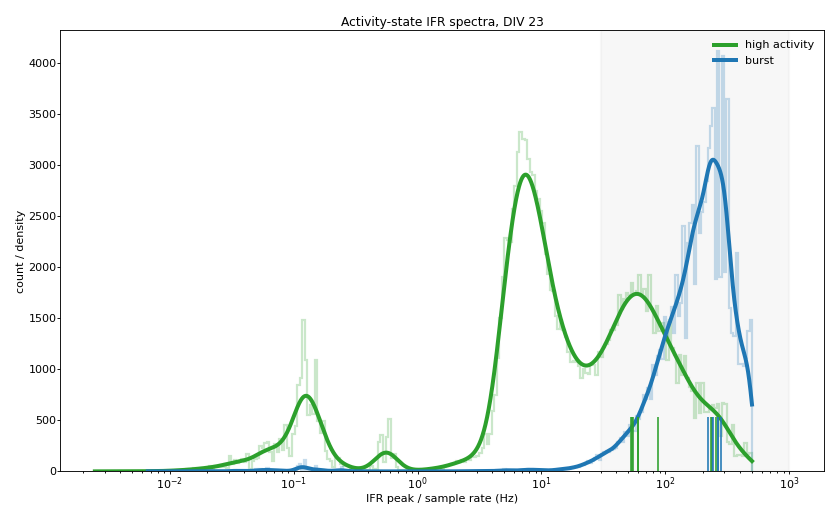

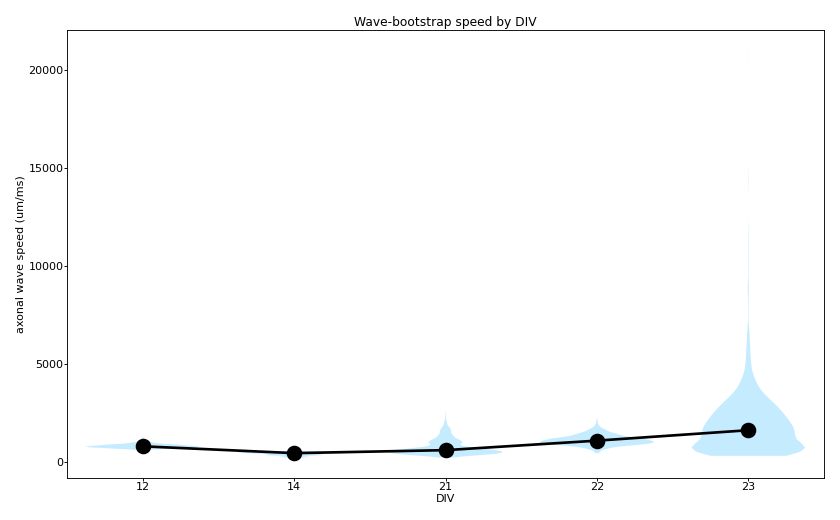

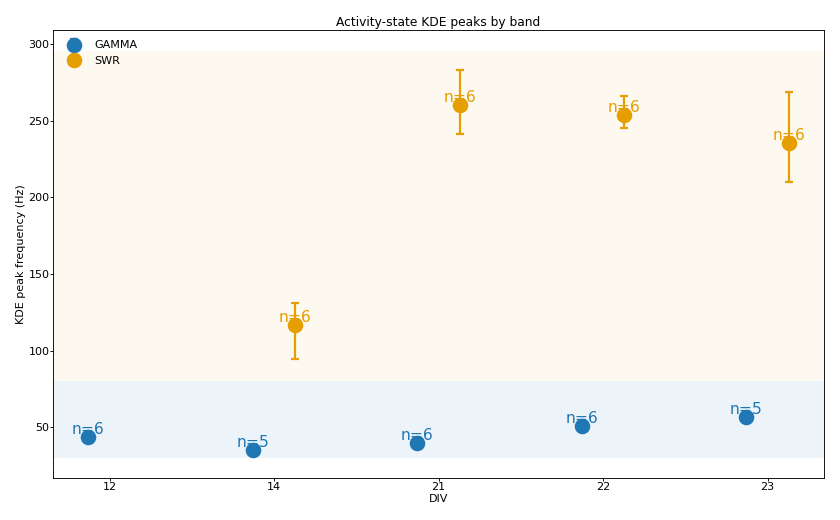

In [10]:

fig, ax = plt.subplots(figsize=(5.2, 3.2))
draw_superposed_ifr_kde(ax, div=23)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 3.2))
draw_wave_bootstrap_by_div(ax)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 3.2))
draw_peak_band_ci_panel(ax)
fig.tight_layout()
plt.show()

fig = draw_recording_peak_bootstrap_matrix(figsize=(13, 9))
plt.show()


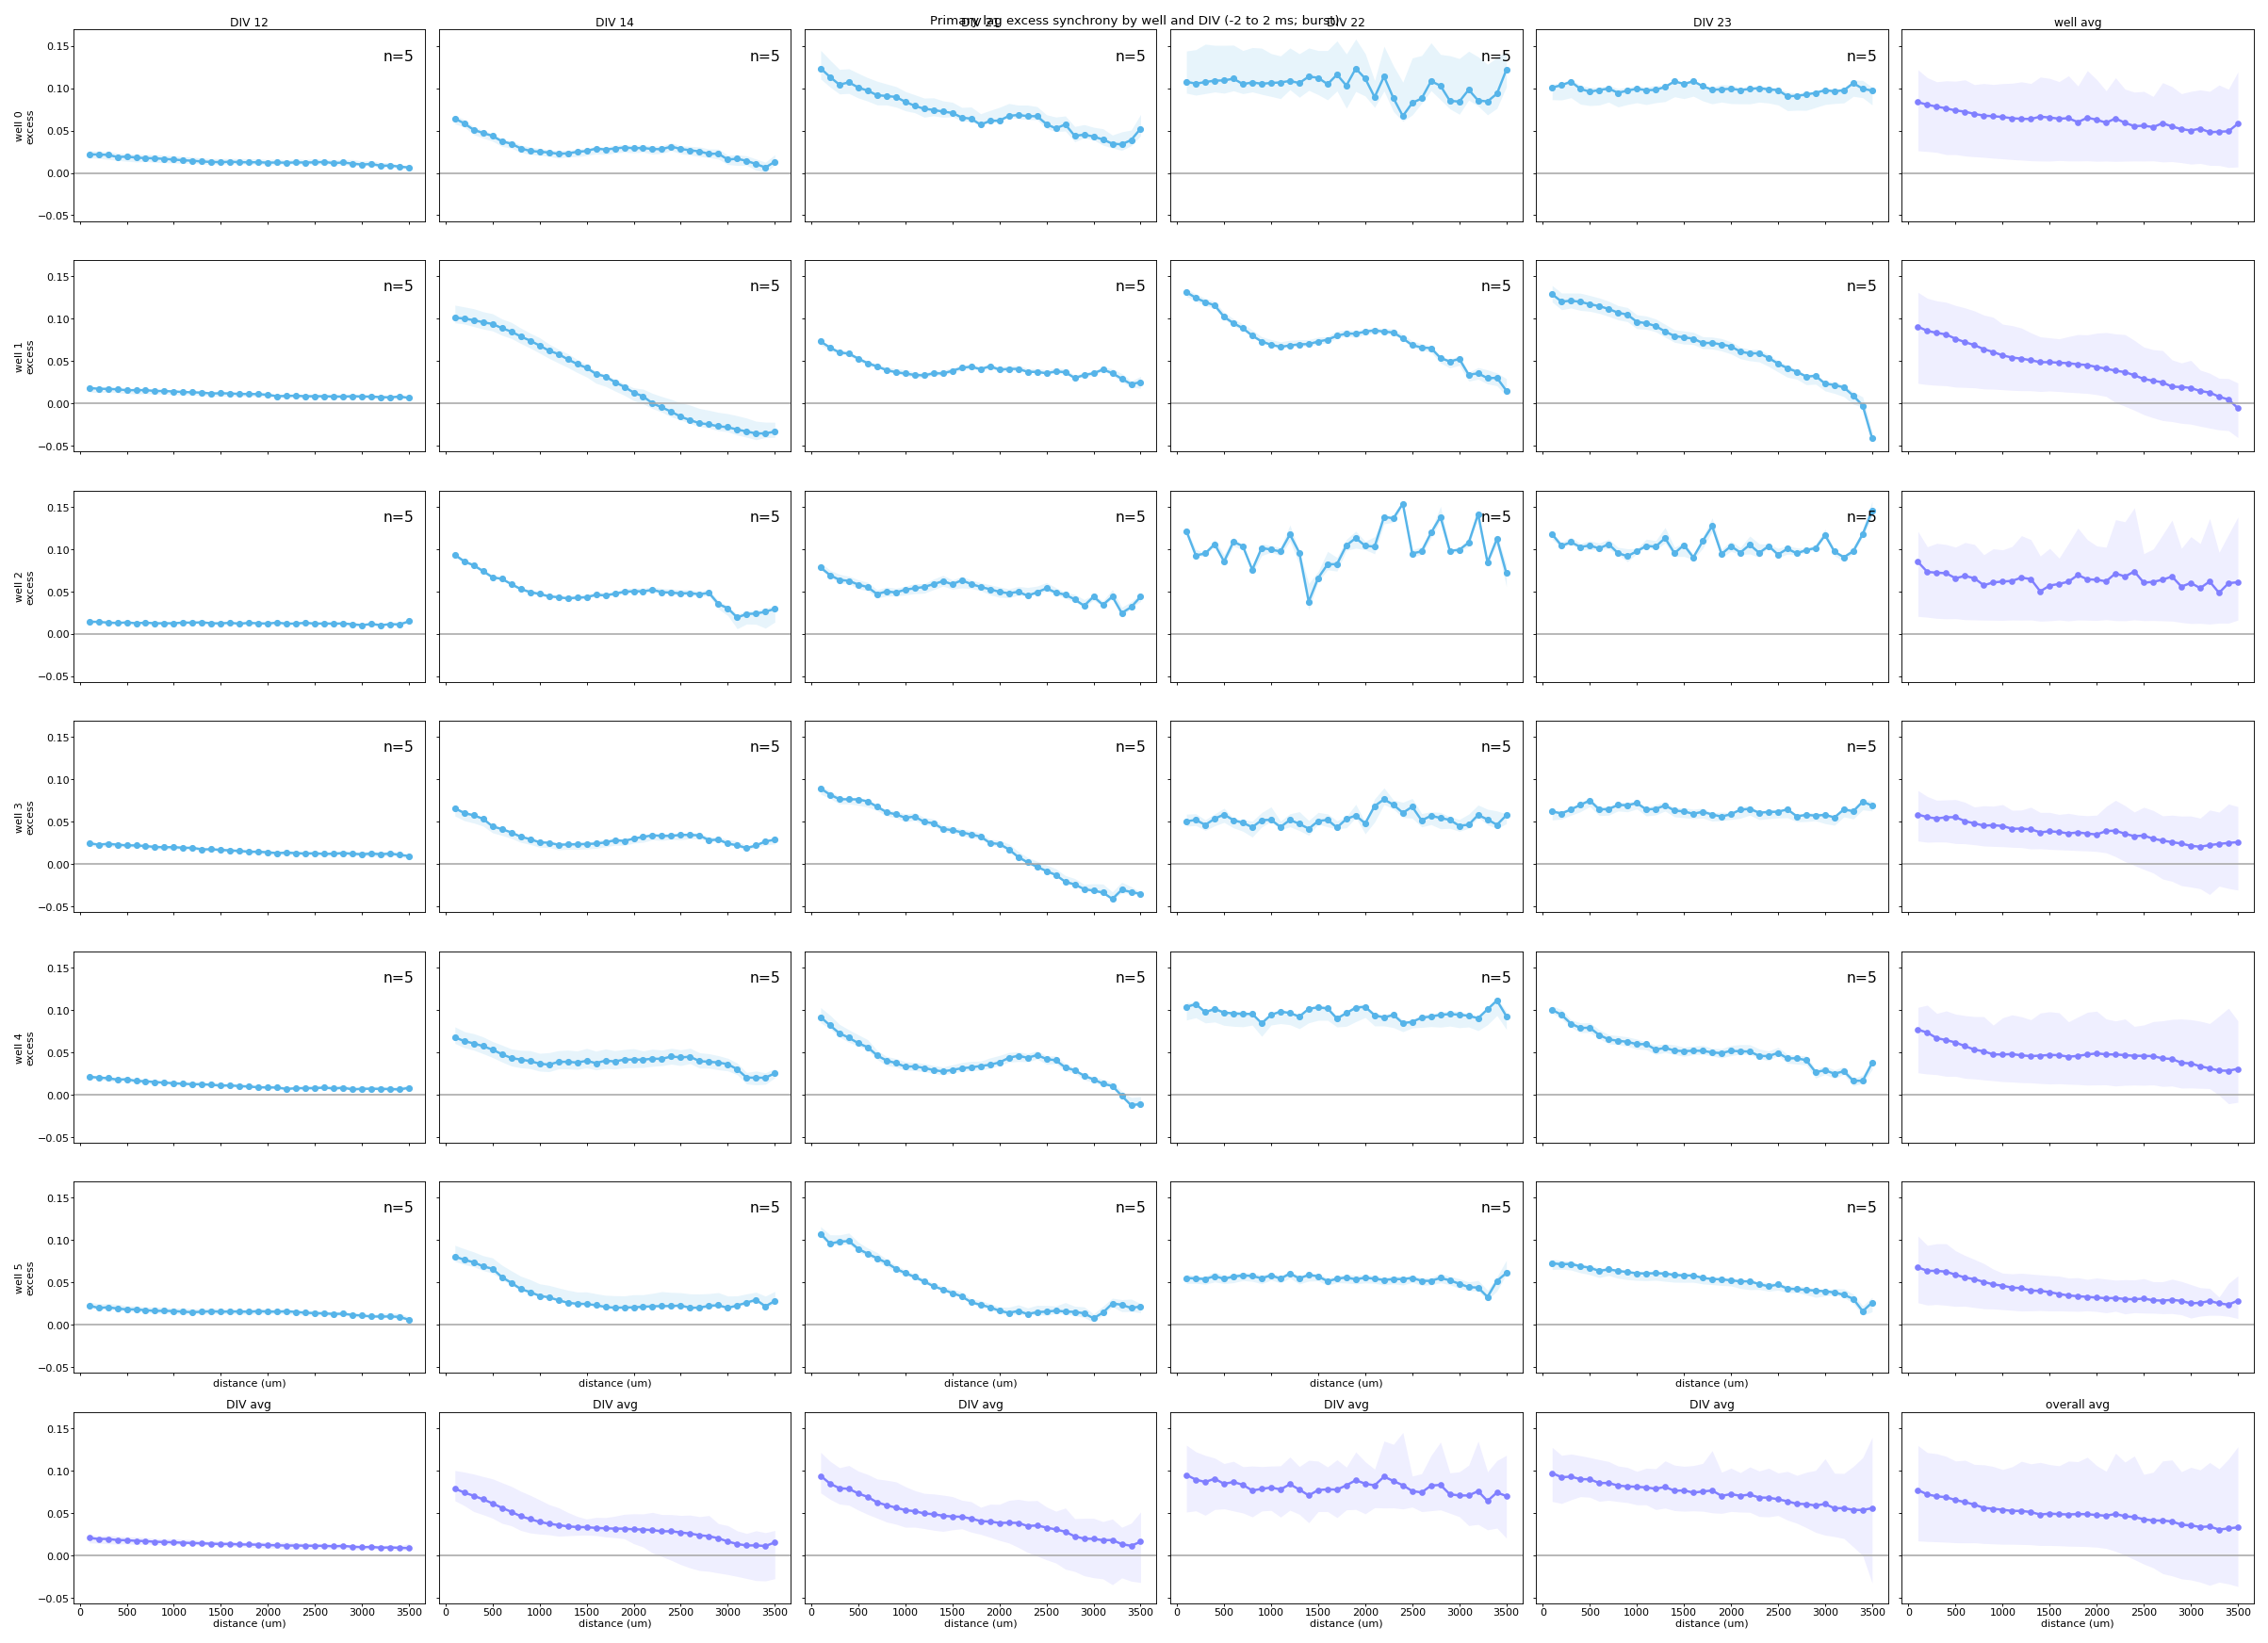

In [11]:

if not primary_distance_summary.empty:
    fig = draw_excess_synchrony_grid(primary_distance_summary, figsize=(15, 11))
    plt.show()
else:
    print("No primary synchrony summary was available.")


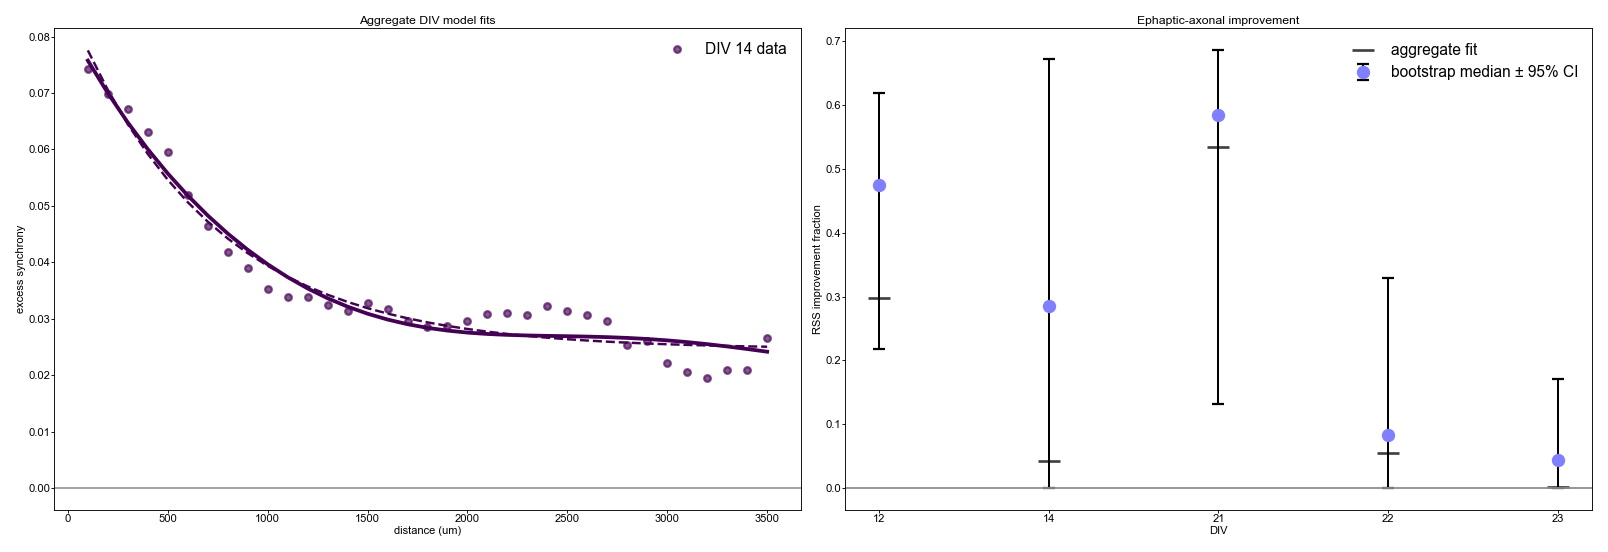

,div,skip_reason,n_points,model_peak_band,n_gamma_peaks,n_gamma_recordings,gamma_peak_mean_hz,v_eph_um_s,v_ax_um_s,axonal_offset,...,delta_bic_ephaptic_minus_axonal_bootstrap_mean,delta_bic_ephaptic_minus_axonal_bootstrap_median,delta_bic_ephaptic_minus_axonal_bootstrap_n,delta_bic_ephaptic_minus_axonal_ci_low,delta_bic_ephaptic_minus_axonal_ci_high,correlation_coefficient_bootstrap_mean,correlation_coefficient_bootstrap_median,correlation_coefficient_bootstrap_n,correlation_coefficient_ci_low,correlation_coefficient_ci_high
0,12,,35,gamma,7,6,43.758931,83295.736378,8.106466e+05,0.008709,...,-18.811853,-18.926133,1000,-30.233024,-5.075938,0.031326,0.033247,1000,0.019532,0.037895
1,14,,35,gamma,6,5,34.822071,83295.736378,4.636583e+05,0.024617,...,-11.160021,-8.202776,1000,-35.494351,3.548079,0.178738,0.240037,1000,-0.033067,0.306852
2,21,,35,gamma,6,6,39.393598,83295.736378,6.152664e+05,0.023452,...,-23.663915,-27.174380,1000,-36.917369,-1.418414,0.186858,0.204743,1000,0.071932,0.233439
3,22,,35,gamma,7,6,51.000447,83295.736378,1.100085e+06,0.072934,...,-0.673875,0.506853,1000,-10.410956,3.523202,0.144438,0.157147,1000,-0.064722,0.286865
4,23,,35,gamma,5,5,56.459883,83295.736378,1.631133e+06,0.016422,...,1.347794,1.969764,1000,-3.014910,3.537555,0.013096,0.015881,1000,-0.090051,0.098518


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
draw_model_fit_panel(axes[0], div=14)
draw_model_improvement_panel(axes[1])
fig.tight_layout()
plt.show()
model_fit_by_div


## Paper-Reportable Statistics


In [13]:
def build_paper_report_tables():
    peak_cols = [
        "div", "band", "n_recordings", "n_recording_states", "n_peak_draws", "mean_peak_hz", "median_recording_peak_hz", "ci_low_hz", "ci_high_hz",
    ]
    peak_stats = peak_band_summary_df[[c for c in peak_cols if c in peak_band_summary_df.columns]].copy() if not peak_band_summary_df.empty else pd.DataFrame(columns=peak_cols)

    wave_cols = [
        "div", "source", "speed_um_per_ms", "speed_ci_low_um_per_ms", "speed_ci_high_um_per_ms", "n_bootstrap_samples", "n_wells",
    ]
    wave_stats = wave_summary_df[[c for c in wave_cols if c in wave_summary_df.columns]].copy() if not wave_summary_df.empty else pd.DataFrame(columns=wave_cols)

    model_cols = [
        "div", "n_points", "model_peak_band", "n_gamma_recordings", "n_gamma_peaks", "gamma_peak_mean_hz", "gamma_peak_mean_hz_bootstrap_median", "gamma_peak_mean_hz_ci_low", "gamma_peak_mean_hz_ci_high",
        "v_eph_um_s", "v_ax_um_s", "axonal_decay_um", "ephaptic_axonal_decay_um", "correlation_coefficient",
        "correlation_coefficient_bootstrap_median", "correlation_coefficient_ci_low", "correlation_coefficient_ci_high",
        "axonal_rss", "ephaptic_rss", "axonal_r2", "ephaptic_r2", "axonal_aic", "ephaptic_aic", "axonal_bic", "ephaptic_bic",
        "rss_improvement_fraction", "rss_improvement_fraction_bootstrap_median", "rss_improvement_fraction_ci_low", "rss_improvement_fraction_ci_high",
        "delta_aic_ephaptic_minus_axonal", "delta_aic_ephaptic_minus_axonal_bootstrap_median", "delta_aic_ephaptic_minus_axonal_ci_low", "delta_aic_ephaptic_minus_axonal_ci_high",
        "delta_bic_ephaptic_minus_axonal", "delta_bic_ephaptic_minus_axonal_bootstrap_median", "delta_bic_ephaptic_minus_axonal_ci_low", "delta_bic_ephaptic_minus_axonal_ci_high",
    ]
    model_stats = model_fit_by_div.copy()
    if "skip_reason" in model_stats:
        model_stats = model_stats[model_stats["skip_reason"].fillna("").astype(str) == ""]
    model_stats = model_stats[[c for c in model_cols if c in model_stats.columns]].copy() if not model_stats.empty else pd.DataFrame(columns=model_cols)

    return peak_stats, wave_stats, model_stats

paper_peak_stats, paper_wave_stats, paper_model_stats = build_paper_report_tables()

try:
    v_eph_um_s, v_eph_mm_s, v_eph_source = load_fixed_ephaptic_speed_um_s()
    print(f"Fixed ephaptic propagation speed input: {v_eph_mm_s:.2f} mm/s = {v_eph_um_s:.0f} um/s; source DIV {v_eph_source['fixed_ephaptic_speed_div']} ({v_eph_source['fixed_ephaptic_speed_scope']}).")
except Exception as exc:
    print(f"Fixed ephaptic propagation speed input unavailable: {exc}")

print(f"Peak-frequency bootstrap: {PEAK_BAND_BOOTSTRAP_REPS} recording-level draws per DIV × band; model peak band = {MODEL_PEAK_BAND!r}.")
print("\nPeak-band frequency statistics:")
display(paper_peak_stats)
print("\nAxonal wave-speed statistics:")
display(paper_wave_stats)
print("\nModel-comparison statistics:")
display(paper_model_stats)

write_table(paper_peak_stats, "paper_report_peak_band_stats.csv")
write_table(paper_wave_stats, "paper_report_wave_speed_stats.csv")
write_table(paper_model_stats, "paper_report_model_comparison_stats.csv")


Fixed ephaptic propagation speed input: 83.30 mm/s = 83296 um/s; source DIV 12 (figure3_hierarchical_all_wells).
Peak-frequency bootstrap: 20 recording-level draws per DIV × band; model peak band = 'gamma'.

Peak-band frequency statistics:


,div,band,n_recordings,n_peaks,mean_peak_hz,median_recording_peak_hz,ci_low_hz,ci_high_hz
0,12,gamma,6,7,43.758931,43.231924,40.112628,45.599980
1,14,gamma,5,6,34.822071,32.374696,33.349493,38.361997
2,14,swr,6,6,116.479774,112.105098,94.717743,131.211063
3,21,gamma,6,6,39.393598,39.407370,36.866887,42.089613
4,21,swr,6,9,260.184313,244.321877,241.681000,283.317251
5,22,gamma,6,7,51.000447,50.560396,47.145488,54.282614
6,22,swr,6,8,253.767021,260.588029,245.224890,266.332032
7,23,gamma,5,5,56.459883,55.146431,53.820874,57.983876
8,23,swr,6,9,235.308799,242.716157,209.874724,269.018333



Axonal wave-speed statistics:


,div,source,speed_um_per_ms,speed_ci_low_um_per_ms,speed_ci_high_um_per_ms,n_bootstrap_samples,n_wells
0,12,hierarchical_per_well,810.646629,653.706418,1062.692323,2000,6
1,14,hierarchical_per_well,463.658307,259.971046,649.739257,2000,6
2,21,hierarchical_per_well,615.266404,336.781322,1759.357418,2000,6
3,22,hierarchical_per_well,1100.085469,673.956183,1718.343477,2000,6
4,23,hierarchical_per_well,1631.133303,384.041746,5586.366353,2000,6



Model-comparison statistics:


,div,n_points,model_peak_band,n_gamma_recordings,n_gamma_peaks,gamma_peak_mean_hz,gamma_peak_mean_hz_bootstrap_median,gamma_peak_mean_hz_ci_low,gamma_peak_mean_hz_ci_high,v_eph_um_s,...,rss_improvement_fraction_ci_low,rss_improvement_fraction_ci_high,delta_aic_ephaptic_minus_axonal,delta_aic_ephaptic_minus_axonal_bootstrap_median,delta_aic_ephaptic_minus_axonal_ci_low,delta_aic_ephaptic_minus_axonal_ci_high,delta_bic_ephaptic_minus_axonal,delta_bic_ephaptic_minus_axonal_bootstrap_median,delta_bic_ephaptic_minus_axonal_ci_low,delta_bic_ephaptic_minus_axonal_ci_high
0,12,35,gamma,6,7,43.758931,43.513796,39.827396,45.908192,83295.736378,...,0.218553,0.619162,-10.332182,-20.481481,-31.788372,-6.631287,-8.776834,-18.926133,-30.233024,-5.075938
1,14,35,gamma,5,6,34.822071,34.822071,33.323805,38.567471,83295.736378,...,0.000208,0.672316,0.454247,-9.758124,-37.049699,1.992730,2.009595,-8.202776,-35.494351,3.548079
2,21,35,gamma,6,6,39.393598,39.039220,36.559802,42.923348,83295.736378,...,0.132472,0.685372,-24.710816,-28.729728,-38.472717,-2.973762,-23.155468,-27.174380,-36.917369,-1.418414
3,22,35,gamma,6,7,51.000447,49.701967,46.702446,54.922115,83295.736378,...,0.000918,0.329034,0.015267,-1.048495,-11.966304,1.967854,1.570615,0.506853,-10.410956,3.523202
4,23,35,gamma,5,5,56.459883,56.283095,53.604769,58.067850,83295.736378,...,0.000508,0.171155,1.936556,0.414416,-4.570258,1.982207,3.491905,1.969764,-3.014910,3.537555


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance/tables/paper_report_model_comparison_stats.csv')

## Compose Figure 4 Draft


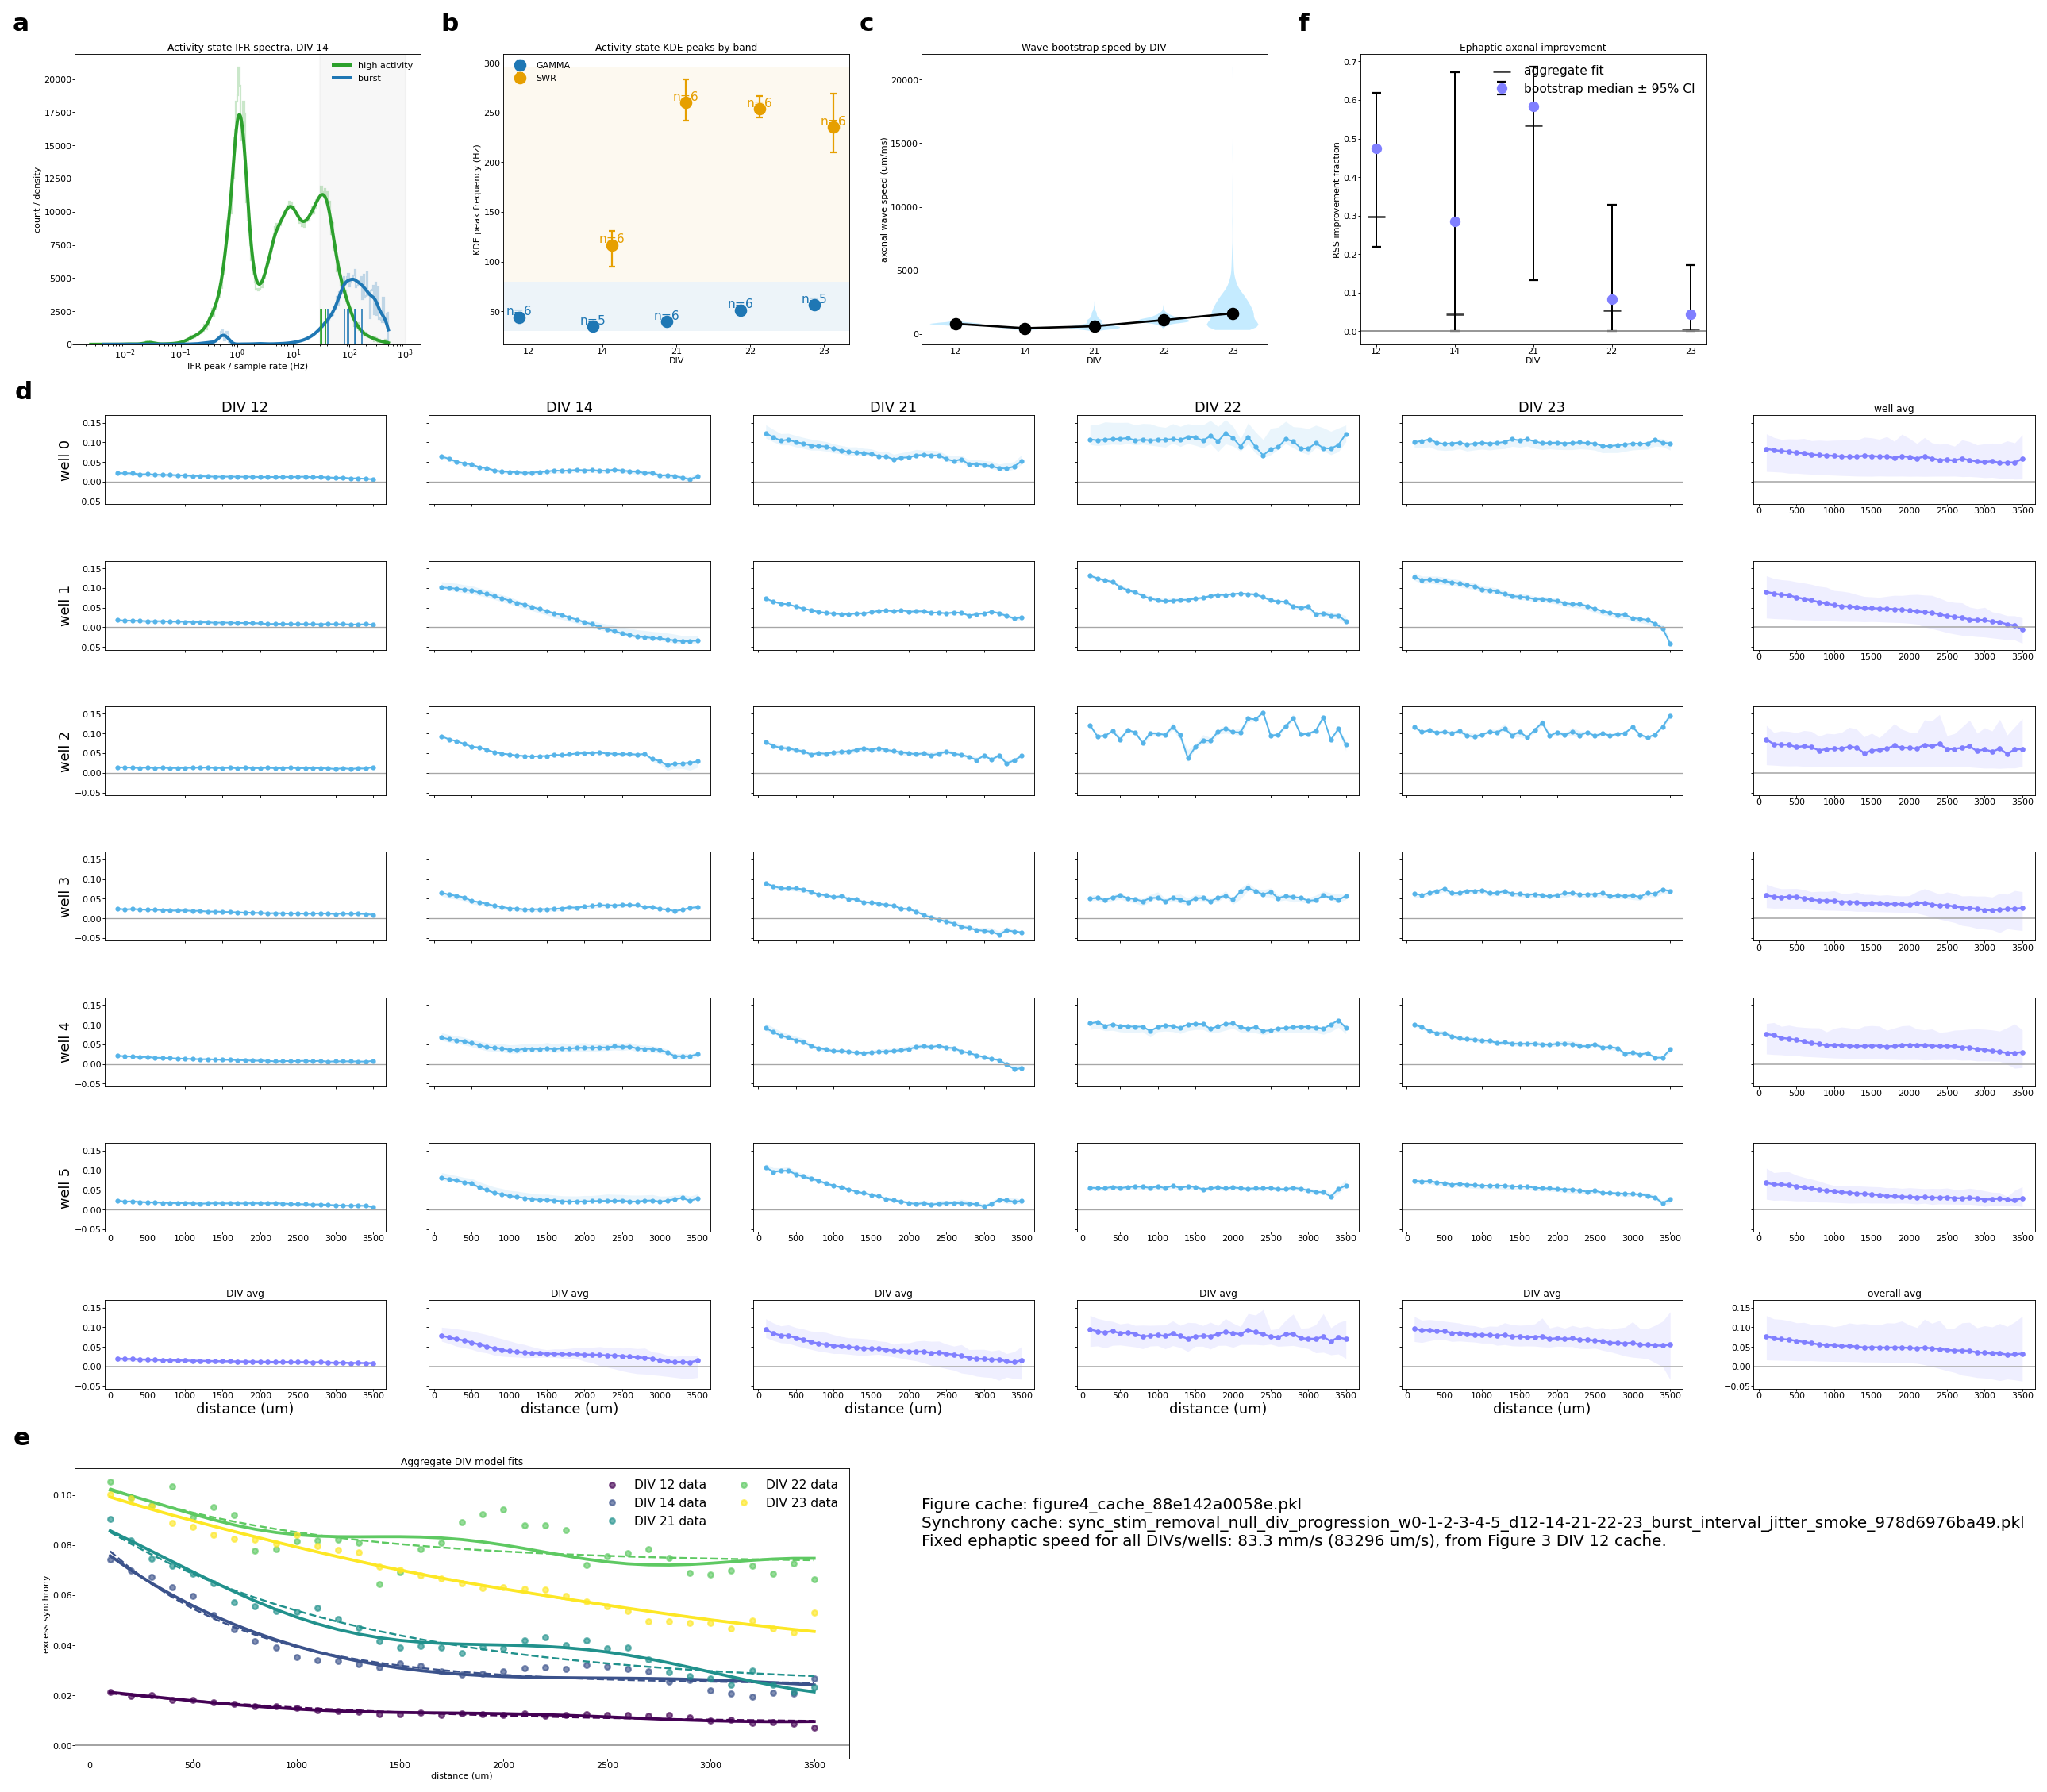

In [14]:

def compose_figure4():
    fig = plt.figure(figsize=(16, 14), constrained_layout=True)
    gs = fig.add_gridspec(4, 4, height_ratios=[1.0, 1.8, 1.8, 1.0])
    ax_a = fig.add_subplot(gs[0, 0])
    draw_superposed_ifr_kde(ax_a, div=EXAMPLE_DIV)
    ax_a.text(-0.18, 1.08, "a", transform=ax_a.transAxes, fontweight="bold", fontsize=14)

    ax_peak = fig.add_subplot(gs[0, 1])
    draw_peak_band_ci_panel(ax_peak)
    ax_peak.text(-0.18, 1.08, "b", transform=ax_peak.transAxes, fontweight="bold", fontsize=14)

    ax_b = fig.add_subplot(gs[0, 2])
    draw_wave_bootstrap_by_div(ax_b)
    ax_b.text(-0.18, 1.08, "c", transform=ax_b.transAxes, fontweight="bold", fontsize=14)

    ax_d = fig.add_subplot(gs[0, 3])
    draw_model_improvement_panel(ax_d)
    ax_d.text(-0.18, 1.08, "f", transform=ax_d.transAxes, fontweight="bold", fontsize=14)

    # Compact synchrony grid as an inset-style raster of curves.
    sub_gs = gs[1:3, :].subgridspec(len(REQUESTED_WELLS) + 1, len(REQUESTED_DIVS) + 1, wspace=0.12, hspace=0.18)
    axes = np.empty((len(REQUESTED_WELLS) + 1, len(REQUESTED_DIVS) + 1), dtype=object)
    y_col = "excess_sync_median" if "excess_sync_median" in primary_distance_summary else "excess_sync_mean"
    y_vals = primary_distance_summary[y_col].to_numpy(float) if not primary_distance_summary.empty else np.array([0, 0.1])
    y_min = min(0.0, float(np.nanmin(y_vals))) if np.isfinite(y_vals).any() else 0.0
    y_max = max(0.01, float(np.nanmax(y_vals))) if np.isfinite(y_vals).any() else 0.1
    pad = 0.08 * (y_max - y_min)
    for i in range(len(REQUESTED_WELLS) + 1):
        for j in range(len(REQUESTED_DIVS) + 1):
            axes[i, j] = fig.add_subplot(sub_gs[i, j])
    for i, well in enumerate(REQUESTED_WELLS):
        for j, div in enumerate(REQUESTED_DIVS):
            ax = axes[i, j]
            df = primary_distance_summary[(primary_distance_summary["well"].astype(int) == int(well)) & (primary_distance_summary["div"].astype(int) == int(div))].sort_values("distance_bin_center_um")
            if not df.empty:
                ax.plot(df["distance_bin_center_um"], df[y_col], marker="o", ms=1.8, lw=0.9, color=PAPER_COLORS.get("secondary", "#1f77b4"))
                if "excess_sync_ci_low" in df and "excess_sync_ci_high" in df:
                    ax.fill_between(df["distance_bin_center_um"].to_numpy(float), df["excess_sync_ci_low"].to_numpy(float), df["excess_sync_ci_high"].to_numpy(float), color=PAPER_COLORS.get("secondary", "#1f77b4"), alpha=0.12, lw=0)
            ax.axhline(0, color="0.65", lw=0.6)
            ax.set_ylim(y_min - pad, y_max + pad)
            if i == 0:
                ax.set_title(f"DIV {div}", fontsize=8)
            if j == 0:
                ax.set_ylabel(f"well {well}", fontsize=8)
            if i < len(REQUESTED_WELLS) - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])
    for i, well in enumerate(REQUESTED_WELLS):
        ax = axes[i, -1]
        draw_margin_curve(ax, primary_distance_summary[primary_distance_summary["well"].astype(int) == int(well)], y_col, color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"), title="well avg" if i == 0 else None)
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_yticklabels([])
    for j, div in enumerate(REQUESTED_DIVS):
        ax = axes[-1, j]
        draw_margin_curve(ax, primary_distance_summary[primary_distance_summary["div"].astype(int) == int(div)], y_col, color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"), title="DIV avg")
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_xlabel("distance (um)", fontsize=8)
        if j > 0:
            ax.set_yticklabels([])
    draw_margin_curve(axes[-1, -1], primary_distance_summary, y_col, color=PAPER_COLORS.get("ephaptic_axonal", "#d62728"), title="overall avg")
    axes[-1, -1].set_ylim(y_min - pad, y_max + pad)
    axes[0, 0].text(-0.32, 1.18, "d", transform=axes[0, 0].transAxes, fontweight="bold", fontsize=14)

    ax_c = fig.add_subplot(gs[3, :2])
    draw_model_fit_panel(ax_c, div=None)
    ax_c.text(-0.08, 1.08, "e", transform=ax_c.transAxes, fontweight="bold", fontsize=14)

    ax_note = fig.add_subplot(gs[3, 2:])
    ax_note.axis("off")
    speed_txt = ""
    try:
        v_eph_um_s, v_eph_mm_s, v_eph_source = load_fixed_ephaptic_speed_um_s()
        speed_txt = f"Fixed ephaptic speed for all DIVs/wells: {v_eph_mm_s:.1f} mm/s ({v_eph_um_s:.0f} um/s), from Figure 3 DIV {v_eph_source['fixed_ephaptic_speed_div']} cache."
    except Exception as exc:
        speed_txt = f"Fixed ephaptic speed unavailable: {exc}"
    cache_txt = f"Figure cache: {figure_cache_path().name}\nSynchrony cache: {Path(figure_payload.get('synchrony_cache_path', '')).name}\n{speed_txt}"
    ax_note.text(0.0, 0.9, cache_txt, va="top", ha="left", fontsize=9)
    return fig

figure4 = compose_figure4()
plt.show()


## Export


In [15]:

if SAVE_FIGURE:
    export_figure(figure4, OUTPUT_DIR / "figure_4_activity_distance_compilation", formats=("pdf", "svg", "png"), dpi=300)
    print(f"Exported Figure 4 draft to {OUTPUT_DIR}")
else:
    print("SAVE_FIGURE=False; not exporting.")


Exported Figure 4 draft to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure4_activity_distance
